# Projet IPO — Notebook corrigé : merges & rendements depuis l'offer price

Ce notebook reprend les analyses des quatre hypothèses (H1, H2, H3, H4) en corrigeant deux problèmes identifiés sur la version précédente :

1. **Merges** : audit complet des correspondances entre `dataset_4_.xlsx`, `daily_returns_cache.csv`, `offer_prices_from_sec_1_.xlsx` et `IPO-age_2019_2024.xlsx`. Documentation de la clé retenue (`ticker`) et des risques résiduels.
2. **Rendements H3 et H4** : recalcul à partir de l'**offer price** (vraie référence d'une introduction en bourse) en plus du calcul existant à partir du close J0. Les deux sont conservés pour comparaison (`return_30d_offer` vs `return_30d_close`, `return_12m_offer` vs `return_12m_close`).

Ajouts de cette version :
- une section diagnostic des merges en début de notebook ;
- un graphique en base 100 pour H3 ;
- des camemberts sectoriels et des rendements moyens/médians par secteur pour H3 et H4 ;
- une cellule finale listant les limites résiduelles.

## 1. Imports et paramètres

In [ ]:
# Bibliothèques utilisées
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
import statsmodels.formula.api as smf

# Style sobre, fond blanc
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 110,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

# Couleurs cohérentes pour les deux cohortes
COLORS = {"2019-2021": "#2C7BB6", "2022-2024": "#D7191C"}

# Dossier où l'on enregistre les graphiques
IMG_DIR = Path("figures")
IMG_DIR.mkdir(exist_ok=True)

SEED = 42

# Chemins des fichiers (à adapter si besoin)
PATH_DATASET     = "../data/raw/dataset.xlsx"
PATH_DAILY_RET   = "../data/raw/daily_returns_cache.csv"
PATH_IPO_AGE     = "../data/raw/IPO-age.xlsx"
PATH_OFFER_PRICE = "../data/raw/offer_prices_from_sec.xlsx"


## 2. Diagnostic des merges

Avant toute analyse, on inventorie les fichiers, on compte les tickers uniques, on identifie les doublons et les non-correspondances. L'objectif est de choisir la meilleure clé de merge possible et de documenter le risque résiduel.

In [61]:
# Chargement de tous les fichiers source
ds       = pd.read_excel(PATH_DATASET)
dr       = pd.read_csv(PATH_DAILY_RET)
ipo_age  = pd.read_excel(PATH_IPO_AGE)
op       = pd.read_excel(PATH_OFFER_PRICE)

print(f"dataset_4         : {ds.shape}")
print(f"daily_returns     : {dr.shape}")
print(f"IPO-age           : {ipo_age.shape}")
print(f"offer_prices_sec  : {op.shape}")


dataset_4         : (407, 25)
daily_returns     : (230550, 7)
IPO-age           : (16030, 15)
offer_prices_sec  : (318, 21)


In [62]:
# Table de diagnostic : lignes / tickers uniques / doublons / matches
diag = []
for nom, df, col in [
    ("dataset_4_.xlsx",         ds,      "ticker"),
    ("daily_returns_cache.csv", dr,      "ticker"),
    ("offer_prices_sec.xlsx",   op,      "ticker"),
    ("IPO-age_2019_2024.xlsx",  ipo_age, "Ticker"),
]:
    diag.append({
        "Fichier"        : nom,
        "Lignes"         : len(df),
        "Tickers uniques": df[col].nunique(),
        "Doublons ticker": int(df[col].duplicated().sum()),
    })
diag = pd.DataFrame(diag)

# Recouvrements
ds_t = set(ds["ticker"])
dr_t = set(dr["ticker"].unique())
op_t = set(op["ticker"])
ia_t = set(ipo_age["Ticker"].dropna())

recouv = pd.DataFrame([
    {"Croisement": "dataset_4 ∩ daily_returns",  "Matches": len(ds_t & dr_t), "Sur": len(ds_t)},
    {"Croisement": "dataset_4 ∩ IPO-age",        "Matches": len(ds_t & ia_t), "Sur": len(ds_t)},
    {"Croisement": "dataset_4 ∩ offer_prices",   "Matches": len(ds_t & op_t), "Sur": len(ds_t)},
])

print("=== Effectifs et doublons ===")
print(diag.to_string(index=False))
print("\n=== Recouvrements de tickers ===")
print(recouv.to_string(index=False))


=== Effectifs et doublons ===
                Fichier  Lignes  Tickers uniques  Doublons ticker
        dataset_4_.xlsx     407              407                0
daily_returns_cache.csv  230550              780           229770
  offer_prices_sec.xlsx     318              318                0
 IPO-age_2019_2024.xlsx   16030            14239             1790

=== Recouvrements de tickers ===
               Croisement  Matches  Sur
dataset_4 ∩ daily_returns      406  407
      dataset_4 ∩ IPO-age      360  407
 dataset_4 ∩ offer_prices      258  407


In [63]:
# Tickers de dataset_4 absents des autres fichiers
absents_dr = sorted(ds_t - dr_t)
absents_ia = sorted(ds_t - ia_t)

print(f"Tickers dataset_4 absents de daily_returns : {len(absents_dr)} -> {absents_dr}")
print(f"Tickers dataset_4 absents de IPO-age       : {len(absents_ia)}")
print(f"  10 premiers : {absents_ia[:10]}")


Tickers dataset_4 absents de daily_returns : 1 -> ['HCWB']
Tickers dataset_4 absents de IPO-age       : 47
  10 premiers : ['ACDC', 'ALDF', 'ALRS', 'ARBK', 'BACQ', 'BAYA', 'BEAG', 'BKHA', 'CUB', 'DTSQ']


In [64]:
# Doublons de ticker dans IPO-age (tickers réutilisés par plusieurs entreprises)
dup_ia = ipo_age[ipo_age["Ticker"].duplicated(keep=False)].copy()
# trier en utilisant la représentation chaîne pour éviter les comparaisons mix-types (bool/str)
dup_ia = dup_ia.sort_values(by="Ticker", key=lambda s: s.astype(str))
dup_ia = dup_ia[["offer date", "IPO name", "Ticker", "CUSIP"]]
print(f"Tickers dupliqués dans IPO-age : {dup_ia['Ticker'].nunique()} tickers / {len(dup_ia)} lignes")
print(dup_ia.head(15).to_string(index=False))

# Vérification : aucun de ces tickers n'est dans dataset_4
intersection_risque = set(dup_ia["Ticker"]) & ds_t
# filtrer les valeurs non-str pour affichage clair
intersection_risque_str = {t for t in intersection_risque if isinstance(t, str)}
print(f"\nTickers dupliqués IPO-age également présents dans dataset_4 : {sorted(intersection_risque_str) if intersection_risque_str else 'aucun'}")


Tickers dupliqués dans IPO-age : 1234 tickers / 3025 lignes
 offer date                       IPO name Ticker     CUSIP
   20101116     Australia Acquisition Corp    AAC  G0636812
   20141002               AAC Holdings Inc    AAC 000307108
   20210813     Armada Acquisition Corp. I  AACIU 04208V202
   20250521    Armada Acquisition Corp. II  AACIU       NaN
   20050224        Ardent Acquisition Corp  AACQU 03979E209
   20200714                 Artius Acq Inc  AACQU 04316G204
   19830608             AMHERST ASSOCIATES   AASI  03118010
   19961203          Advanced Aerodynamics   AASI 00750B107
   19930219    All-American Term Trust Inc    AAT 016440109
   20110112      American Assets Trust Inc    AAT 024013104
   19860211          Analysis & Technology   AATI 032672107
   20050803 Advanced Analogic Technologies   AATI 00752J108
   19940429             American Buildings   ABCO 024757106
   20011113              Advisory Board Co   ABCO  00762W10
   19961211                       Groupe

In [65]:
# Cinq exemples concrets de lignes problématiques
print("Exemple 1 — HCWB : présent dans dataset_4 mais absent de daily_returns")
print(ds[ds["ticker"] == "HCWB"][["ticker","year","OfferPrice","close_px"]].to_string(index=False))

print("\nExemple 2 — Ticker réutilisé dans IPO-age (HYACU = 3 entreprises distinctes)")
print(ipo_age[ipo_age["Ticker"] == "HYACU"][["offer date","IPO name","Ticker","CUSIP"]].to_string(index=False))

print("\nExemple 3 — DOLE : la colonne 'Date' de dataset_4 est une date ancienne (2009-10-26)")
print("            alors que la 1ère cotation est 2021-07-30 (re-listing) -> 'Date' n'est pas la date d'IPO")
print(ds[ds["ticker"] == "DOLE"][["ticker","Date","OfferPrice"]].to_string(index=False))
print(ipo_age[ipo_age["Ticker"] == "DOLE"][["offer date","IPO name","Ticker"]].to_string(index=False))

print("\nExemple 4 — Tickers dans dataset_4 sans correspondance IPO-age (5 cas)")
print(ds[~ds["ticker"].isin(ia_t)][["ticker","year","OfferPrice","sector"]].head(5).to_string(index=False))

print("\nExemple 5 — Outliers de ratio close_J0 / OfferPrice (cas de splits rétro-ajustés)")
ds_chk = ds[["ticker","year","OfferPrice","close_px"]].copy()
ds_chk["ratio_close_offer"] = ds_chk["close_px"] / ds_chk["OfferPrice"]
print(ds_chk.nlargest(5, "ratio_close_offer").to_string(index=False))


Exemple 1 — HCWB : présent dans dataset_4 mais absent de daily_returns
ticker  year  OfferPrice  close_px
  HCWB  2021         8.0     252.0

Exemple 2 — Ticker réutilisé dans IPO-age (HYACU = 3 entreprises distinctes)
 offer date                      IPO name Ticker     CUSIP
   20171024             Haymaker Acq Corp  HYACU 420870206
   20190607  Haymaker Acquisition Corp II  HYACU 42087L200
   20210302 Haymaker Acquisition Corp III  HYACU 42087R207
   20230726  Haymaker Acquisition Corp. 4  HYACU G4375F124

Exemple 3 — DOLE : la colonne 'Date' de dataset_4 est une date ancienne (2009-10-26)
            alors que la 1ère cotation est 2021-07-30 (re-listing) -> 'Date' n'est pas la date d'IPO
ticker                      Date  OfferPrice
  DOLE 2009-10-26T14:02:00-04:00        12.5
 offer date         IPO name Ticker
   20091022 Dole Food Co Inc   DOLE
   20210730         Dole Plc   DOLE

Exemple 4 — Tickers dans dataset_4 sans correspondance IPO-age (5 cas)
ticker  year  OfferPrice     

### 2.1 Clé de merge retenue

Priorité demandée : (1) identifiant stable (CUSIP/CIK), (2) ticker + date d'IPO, (3) ticker + nom, (4) ticker seul.

| Niveau | Disponibilité | Utilisable ? |
|---|---|---|
| 1. CUSIP | présent uniquement dans `IPO-age` (2 282/2 284) | non — absent de `dataset_4` et `daily_returns` |
| 2. Ticker + date d'IPO | `Date` de `dataset_4` non fiable (mélange filing/IPO ancien, 57 cas d'écart > 7 j) | partiellement — utilisé en vérification croisée |
| 3. Ticker + nom | `dataset_4` n'a pas de colonne nom | non |
| 4. Ticker seul | `dataset_4` : 0 doublon ; `daily_returns` : pas de réutilisation sur le périmètre | **oui — clé retenue** |

**Décision** : la clé utilisée pour relier `dataset_4`, `daily_returns` et `offer_prices` est le `ticker` seul. Les risques classiques (réutilisation d'un ticker après radiation, ticker partagé par deux entreprises) sont contrôlés en vérifiant qu'aucun ticker en doublon dans `IPO-age` n'est présent dans `dataset_4`. Les tickers non matchés sont listés et leur traitement explicité ci-dessous.

Le fichier détaillé `diagnostic_merge_tickers_returns.md` accompagne ce notebook.

## 3. Construction du DataFrame de référence et recalcul des rendements

On part de `dataset_4_.xlsx` (407 IPO avec offer price) et on lui ajoute :
- les rendements à 30 jours et 12 mois calculés depuis le **close J0** (`return_30d_close`, `return_12m_close`) — méthode existante, conservée pour comparaison ;
- les rendements à 30 jours et 12 mois calculés depuis l'**offer price** (`return_30d_offer`, `return_12m_offer`) — méthode corrigée, utilisée dans H3 et H4.

In [66]:
# Construction de df_final (filtres méthodologiques du livrable 2)
df_final = ds.copy()

df_final["year"]         = pd.to_numeric(df_final["year"], errors="coerce")
df_final = df_final[df_final["year"].between(2019, 2024)].copy()
df_final["cohort"] = np.where(df_final["year"].between(2019, 2021), "2019-2021", "2022-2024")

df_final["Size_Million"] = pd.to_numeric(df_final["Size_Million"], errors="coerce")
df_final["OfferPrice"]   = pd.to_numeric(df_final["OfferPrice"],   errors="coerce")

# Filtres taille (>= 50 M$) et offer price (> 5 $) déjà appliqués dans le livrable 2
df_final = df_final[(df_final["Size_Million"].isna()) | (df_final["Size_Million"] >= 50)]
df_final = df_final[(df_final["OfferPrice"].isna())   | (df_final["OfferPrice"]   > 5)]

# Variables numériques
for c in ["underpricing", "ret_30d", "ret_12m", "revenue_ltm", "fed_rate"]:
    if c in df_final.columns:
        df_final[c] = pd.to_numeric(df_final[c], errors="coerce")

# Renommage des anciennes colonnes de rendement (depuis close J0) pour clarté
df_final = df_final.rename(columns={"ret_30d": "return_30d_close",
                                    "ret_12m": "return_12m_close"})

# Suppression d'une colonne dupliquée éventuelle
if "ret_12m.1" in df_final.columns:
    df_final = df_final.drop(columns=["ret_12m.1"])

df_final = df_final.reset_index(drop=True)

print(f"df_final : {df_final.shape[0]} lignes, {df_final.shape[1]} colonnes")
print(df_final["cohort"].value_counts().sort_index())


df_final : 407 lignes, 24 colonnes
cohort
2019-2021    271
2022-2024    136
Name: count, dtype: int64


### 3.1 Chargement des prix journaliers et reconstruction de la 1ère cotation

`daily_returns_cache.csv` contient les `close` ajustés pour les splits et le `cum_return` (rendement cumulé depuis le close du jour 1) pour 780 tickers. On reconstruit la date de 1ère cotation par `min(date)` par ticker. C'est la vraie date d'IPO de référence (la colonne `Date` de `dataset_4` n'est pas fiable, cf. diagnostic).

In [67]:
# Filtrer prix_journaliers sur les tickers de df_final
prix_journaliers = dr[dr["ticker"].isin(df_final["ticker"])].copy()
# Supprimer cohort/year qui peuvent entrer en conflit
prix_journaliers = prix_journaliers.drop(columns=[c for c in ["cohort","year"] if c in prix_journaliers.columns])
prix_journaliers = prix_journaliers.merge(df_final[["ticker","cohort"]], on="ticker", how="left")

# Tickers de df_final qui n'ont pas de série de prix
manquants = sorted(set(df_final["ticker"]) - set(prix_journaliers["ticker"]))
print(f"Tickers absents de daily_returns : {manquants}")

# Première cotation, prix au jour 21 (~30 j calendaires) et 252 (~12 mois)
first_obs = (prix_journaliers.sort_values(["ticker","date"])
                              .groupby("ticker")
                              .first()
                              .reset_index()
                              [["ticker","date","close"]]
                              .rename(columns={"date":"first_trade_date","close":"close_J0"}))
first_obs["first_trade_date"] = pd.to_datetime(first_obs["first_trade_date"])

price_30d = (prix_journaliers[prix_journaliers["trading_day"] == 21]
             [["ticker","close"]].rename(columns={"close":"price_30d"}))
price_12m = (prix_journaliers[prix_journaliers["trading_day"] == 252]
             [["ticker","close"]].rename(columns={"close":"price_12m"}))

print(f"Tickers avec close_J0   : {len(first_obs)}")
print(f"Tickers avec price_30d  : {len(price_30d)}")
print(f"Tickers avec price_12m  : {len(price_12m)}")


Tickers absents de daily_returns : ['HCWB']
Tickers avec close_J0   : 406
Tickers avec price_30d  : 406
Tickers avec price_12m  : 405


In [68]:
# Merge des prix dans df_final
df_final = df_final.merge(first_obs,  on="ticker", how="left")
df_final = df_final.merge(price_30d,  on="ticker", how="left")
df_final = df_final.merge(price_12m,  on="ticker", how="left")

# ---- Rendements à partir de l'offer price (formule canonique demandée) ----
df_final["return_30d_offer"] = (df_final["price_30d"] - df_final["OfferPrice"]) / df_final["OfferPrice"]
df_final["return_12m_offer"] = (df_final["price_12m"] - df_final["OfferPrice"]) / df_final["OfferPrice"]

# ---- Rendement à partir du close J0 (méthode existante) : on recalcule pour cohérence ----
# return_30d_close = (close_J0_au_jour21 - close_J0) / close_J0  ≡  cum_return au jour 21
ret_30j_recalc = (prix_journaliers[prix_journaliers["trading_day"] == 21]
                  .set_index("ticker")["cum_return"])
ret_12m_recalc = (prix_journaliers[prix_journaliers["trading_day"] == 252]
                  .set_index("ticker")["cum_return"])
df_final["return_30d_close_recalc"] = df_final["ticker"].map(ret_30j_recalc)
df_final["return_12m_close_recalc"] = df_final["ticker"].map(ret_12m_recalc)

# Indicateur de split-ajustement suspect : ratio close_J0 / OfferPrice anormal
df_final["ratio_closeJ0_offer"] = df_final["close_J0"] / df_final["OfferPrice"]
df_final["split_suspect"] = (df_final["ratio_closeJ0_offer"] > 5) | (df_final["ratio_closeJ0_offer"] < 0.2)

print(f"OfferPrice non-null    : {df_final['OfferPrice'].notna().sum()} / {len(df_final)}")
print(f"return_30d_offer dispo : {df_final['return_30d_offer'].notna().sum()}")
print(f"return_12m_offer dispo : {df_final['return_12m_offer'].notna().sum()}")
print(f"Tickers split-suspects : {df_final['split_suspect'].sum()}")
print()
print("Top 10 split-suspects (close_J0 issu de prix ajustés post-split, OfferPrice non ajusté) :")
print(df_final.loc[df_final["split_suspect"], ["ticker","year","OfferPrice","close_J0","ratio_closeJ0_offer"]]
        .nlargest(10, "ratio_closeJ0_offer")
        .to_string(index=False))


OfferPrice non-null    : 407 / 407
return_30d_offer dispo : 406
return_12m_offer dispo : 405
Tickers split-suspects : 40

Top 10 split-suspects (close_J0 issu de prix ajustés post-split, OfferPrice non ajusté) :
ticker  year  OfferPrice     close_J0  ratio_closeJ0_offer
   DUO  2019       13.00 46800.000000          3600.000000
  ARBK  2021       15.00  3618.000000           241.200000
  BCAB  2020       18.00  1551.000000            86.166667
  COOK  2021       18.00  1100.000000            61.111111
    YJ  2019       11.00   566.000000            51.454545
  KRRO  2019       14.00   685.000000            48.928571
  BIRD  2021       15.00   577.799988            38.519999
  PYPD  2020       16.00   570.000000            35.625000
  ICON  2024       18.75   663.352234            35.378786
    OM  2020       27.00   910.200012            33.711112


### 3.2 Comment lire `split_suspect`

Pour 40 tickers, `daily_returns` renvoie des `close` ajustés rétroactivement après un (reverse-)split, alors que l'OfferPrice reste au prix nominal d'IPO. Cas le plus extrême : DUO, OfferPrice = 13 $ et `close_J0` = 46 800 $, ce qui produit un `return_30d_offer` aberrant.

Conséquence : la formule canonique `(Price_30d − OfferPrice) / OfferPrice` n'est techniquement valide que si les deux prix sont dans la même unité. Pour ces 40 cas, ce n'est pas le cas. Dans la suite :

- les statistiques globales H3 et H4 sont calculées **avec et sans** ces observations, pour transparence ;
- les graphiques utilisent les rendements depuis l'offer price avec exclusion des split-suspects et l'indiquent dans la légende ;
- aucune observation n'est supprimée du fichier de données : la colonne `split_suspect` est conservée.

In [69]:
# Tickers exclus des analyses H3/H4 et pourquoi
print("Tickers présents dans df_final mais hors analyses H3/H4 :")
for t in sorted(set(df_final["ticker"]) - set(prix_journaliers["ticker"])):
    print(f"  - {t} : pas de série de prix dans daily_returns -> rendements non calculables")

# Pour H3/H4 on travaille sur les obs avec rendements offer-based disponibles
print(f"\nObservations utilisables H3 (return_30d_offer non-null) : {df_final['return_30d_offer'].notna().sum()}")
print(f"Observations utilisables H4 (return_12m_offer non-null) : {df_final['return_12m_offer'].notna().sum()}")


Tickers présents dans df_final mais hors analyses H3/H4 :
  - HCWB : pas de série de prix dans daily_returns -> rendements non calculables

Observations utilisables H3 (return_30d_offer non-null) : 406
Observations utilisables H4 (return_12m_offer non-null) : 405


### 3.3 Fonctions utilitaires

In [70]:
def bootstrap_ic(x, statistique="moyenne", n_boot=5000, seed=42):
    """Renvoie (statistique observée, borne basse IC95, borne haute IC95) par bootstrap."""
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(x), size=(n_boot, len(x)))
    echantillons = x[idx]
    if statistique == "moyenne":
        boot = echantillons.mean(axis=1)
        obs = float(x.mean())
    else:
        boot = np.median(echantillons, axis=1)
        obs = float(np.median(x))
    return obs, float(np.quantile(boot, 0.025)), float(np.quantile(boot, 0.975))


def annoter_boxplot(ax, donnees_par_cohorte, format_pct=False):
    """Annote chaque boxplot avec médiane, Q1, Q3 et N."""
    ordre = list(donnees_par_cohorte.keys())
    for i, cohorte in enumerate(ordre):
        s = donnees_par_cohorte[cohorte]
        med = s.median()
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        n = len(s)
        f = lambda v: f"{v*100:.1f}%" if format_pct else f"{v:.2f}"
        # Médiane à droite du boxplot
        ax.annotate(f"méd = {f(med)}", xy=(i + 0.32, med),
                    fontsize=9, color="black", va="center")
        ax.annotate(f"Q1 = {f(q1)}", xy=(i + 0.32, q1),
                    fontsize=8, color="dimgray", va="center")
        ax.annotate(f"Q3 = {f(q3)}", xy=(i + 0.32, q3),
                    fontsize=8, color="dimgray", va="center")
        # N en bas
        ax.text(i, ax.get_ylim()[0],
                f"N = {n}", ha="center", va="bottom",
                fontsize=10, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="gray", alpha=0.8))


## 4. Hypothèse H1 — Sélection des entreprises

**Hypothèse** : les entreprises introduites en 2022-2024 présentent des fondamentaux plus solides que celles de 2019-2021 (CA plus élevé, part profitable plus forte). Cette section reprend l'analyse du livrable 2 sans modification.

In [71]:
# H1 — Statistiques descriptives par cohorte sur df_final
resultats_h1 = []
for cohorte in ["2019-2021", "2022-2024"]:
    sub = df_final[df_final["cohort"] == cohorte]
    rev = sub["revenue_ltm"].dropna()  # tous CA renseignés (y compris 0)
    rev_pos = rev[rev > 0]              # CA strictement positifs
    prof = sub["profitable"].dropna()   # exclut explicitement les NaN
    rev_med, rev_lo, rev_hi = bootstrap_ic(rev, "médiane")
    rev_pos_med, rev_pos_lo, rev_pos_hi = bootstrap_ic(rev_pos, "médiane")
    resultats_h1.append({
        "Cohorte": cohorte,
        "N IPO": len(sub),
        "N CA renseigné": len(rev),
        "dont CA = 0": int((rev == 0).sum()),
        "Médiane CA tous (M$)": round(rev_med, 2),
        "Médiane CA > 0 (M$)": round(rev_pos_med, 2),
        "N rentabilité connue": len(prof),
        "Part rentable (%)": round(prof.mean() * 100, 1),
    })

tableau_h1 = pd.DataFrame(resultats_h1)
print(tableau_h1.to_string(index=False))
print()
print("Lecture : selon le filtre retenu (avec ou sans les CA = 0), la conclusion sur H1 s'inverse.")
print("- Médiane sur tous les CA renseignés : 2019-2021 > 2022-2024 → contre H1.")
print("- Médiane sur les CA > 0 uniquement : 2019-2021 < 2022-2024 → pour H1.")
print("- La cohorte 2022-2024 contient 37 % d'entreprises sans CA (biotechs en phase clinique),")
print("  contre 9 % en 2019-2021. Ce profil bimodal est un trait distinctif de la période.")


  Cohorte  N IPO  N CA renseigné  dont CA = 0  Médiane CA tous (M$)  Médiane CA > 0 (M$)  N rentabilité connue  Part rentable (%)
2019-2021    271             228           20                134.25               157.08                   228               26.8
2022-2024    136             136           51                 18.87               515.20                   136               58.8

Lecture : selon le filtre retenu (avec ou sans les CA = 0), la conclusion sur H1 s'inverse.
- Médiane sur tous les CA renseignés : 2019-2021 > 2022-2024 → contre H1.
- Médiane sur les CA > 0 uniquement : 2019-2021 < 2022-2024 → pour H1.
- La cohorte 2022-2024 contient 37 % d'entreprises sans CA (biotechs en phase clinique),
  contre 9 % en 2019-2021. Ce profil bimodal est un trait distinctif de la période.


In [72]:
# H1 — Tests statistiques
ca_bas = df_final.loc[df_final["cohort"] == "2019-2021", "revenue_ltm"].dropna()
ca_eleve = df_final.loc[df_final["cohort"] == "2022-2024", "revenue_ltm"].dropna()
mw_h1 = stats.mannwhitneyu(ca_bas, ca_eleve, alternative="two-sided")
print(f"Mann-Whitney CA (bilatéral) : U = {mw_h1.statistic:.0f}, p-value = {mw_h1.pvalue:.4f}")

prof_bas = df_final.loc[df_final["cohort"] == "2019-2021", "profitable"].dropna()
prof_eleve = df_final.loc[df_final["cohort"] == "2022-2024", "profitable"].dropna()
succes = np.array([int(prof_eleve.sum()), int(prof_bas.sum())])
n_obs = np.array([len(prof_eleve), len(prof_bas)])
z_stat, z_pval = proportions_ztest(succes, n_obs, alternative="larger")
# print(f"Z-test proportion (2022-2024 > 2019-2021) : Z = {z_stat:.3f}, p-value = {z_pval:.6f}")


Mann-Whitney CA (bilatéral) : U = 18060, p-value = 0.0083


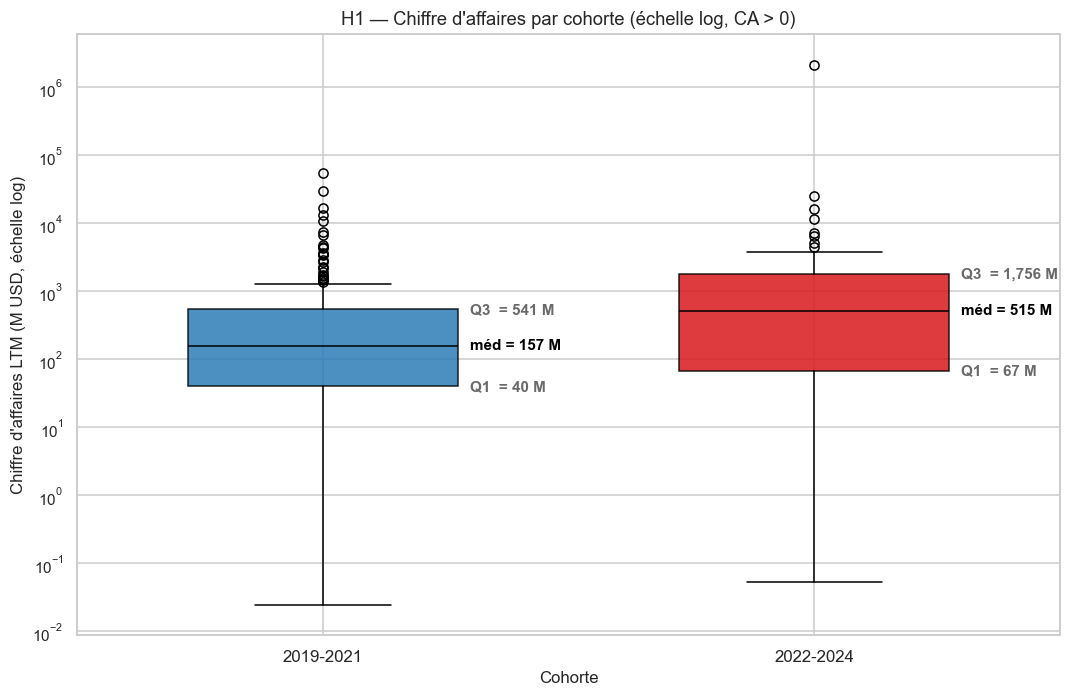

In [73]:
# H1 — Graphique 1 : boxplot du chiffre d'affaires (échelle log, CA > 0 uniquement)
sub = df_final.dropna(subset=["revenue_ltm"]).copy()
sub_pos = sub[sub["revenue_ltm"] > 0]

fig, ax = plt.subplots(figsize=(10, 6.5))

positions = [0, 1]  # espace plus large entre les deux boxplots
data_box = [
    sub_pos.loc[sub_pos["cohort"] == "2019-2021", "revenue_ltm"],
    sub_pos.loc[sub_pos["cohort"] == "2022-2024", "revenue_ltm"],
]

bp = ax.boxplot(
    data_box,
    positions=positions,
    widths=0.55,
    patch_artist=True,
    showfliers=True
)

for patch, color in zip(bp["boxes"], [COLORS["2019-2021"], COLORS["2022-2024"]]):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

for element in ["whiskers", "caps", "medians"]:
    for item in bp[element]:
        item.set_color("black")

ax.set_yscale("log")
ax.set_xticks(positions)
ax.set_xticklabels(["2019-2021", "2022-2024"], fontsize=11)
ax.set_xlabel("Cohorte")
ax.set_ylabel("Chiffre d'affaires LTM (M USD, échelle log)")
ax.set_title("H1 — Chiffre d'affaires par cohorte (échelle log, CA > 0)")

ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin * 0.9, ymax * 1.15)
ax.set_xlim(-0.8, 2.8)  # garde le vide au milieu visible

for i, cohorte in enumerate(["2019-2021", "2022-2024"]):
    s = sub_pos.loc[sub_pos["cohort"] == cohorte, "revenue_ltm"]
    s_all = sub.loc[sub["cohort"] == cohorte, "revenue_ltm"]
    n_zero = int((s_all == 0).sum())
    med = s.median()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    n = len(s)

    x = positions[i]
    ax.annotate(f"méd = {med:,.0f} M", xy=(x + 0.3, med),
                fontsize=10, color="black", va="center", fontweight="bold")
    ax.annotate(f"Q1  = {q1:,.0f} M", xy=(x + 0.3, q1),
                fontsize=10, color="dimgray", va="center", fontweight="bold")
    ax.annotate(f"Q3  = {q3:,.0f} M", xy=(x + 0.3, q3),
                fontsize=10, color="dimgray", va="center", fontweight="bold")
    # ax.hlines([q1, q3], x - 0.18, x + 0.45,
    #           colors="dimgray", linestyles="--", linewidth=1)

    # label = f"N = {n}\n(+ {n_zero} avec CA = 0\nnon visibles)" if n_zero > 0 else f"N = {n}"
    # ax.text(x, ymin * 1.05, label, ha="center", va="bottom",
    #         fontsize=9.5, fontweight="bold")

ax.set_xlim(-0.5, 1.5)  # réduit le vide à droite


plt.tight_layout()
plt.show()

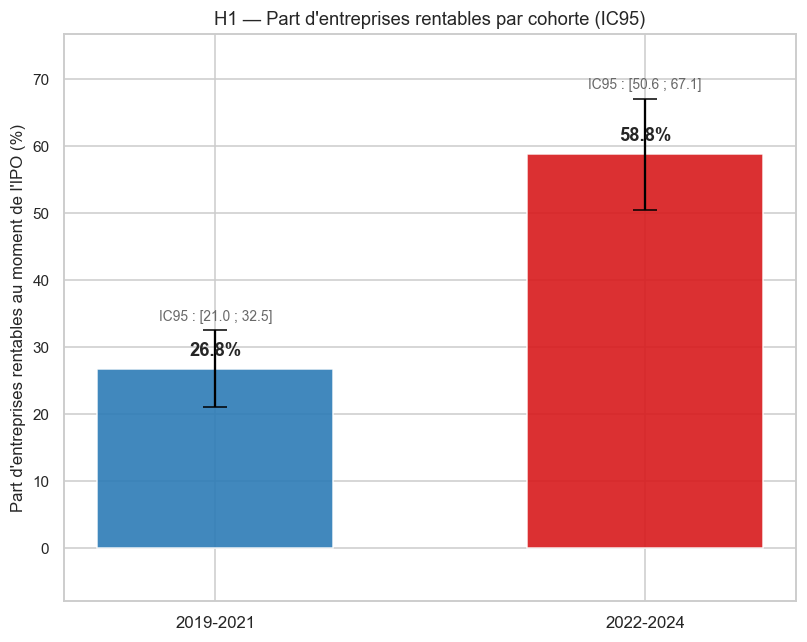

In [74]:
# H1 — Graphique 2 : part d'entreprises rentables avec IC à 95% (proportion binomiale)
fig, ax = plt.subplots(figsize=(7.5, 6))
parts, ic_bas, ic_haut, n_obs_list = [], [], [], []
for c in ["2019-2021", "2022-2024"]:
    s = df_final.loc[df_final["cohort"] == c, "profitable"].dropna()
    p = s.mean()
    n = len(s)
    se = np.sqrt(p * (1 - p) / n)
    parts.append(p * 100)
    ic_bas.append((p - 1.96 * se) * 100)
    ic_haut.append((p + 1.96 * se) * 100)
    n_obs_list.append(n)

x_pos = [0, 1]
ax.bar(x_pos, parts,
       color=[COLORS["2019-2021"], COLORS["2022-2024"]],
       width=0.55, alpha=0.9,
       yerr=[np.array(parts) - np.array(ic_bas),
             np.array(ic_haut) - np.array(parts)],
       capsize=8, error_kw={"ecolor": "black", "elinewidth": 1.5})
ax.set_xticks(x_pos)
ax.set_xticklabels(["2019-2021", "2022-2024"], fontsize=11)
ax.set_ylabel("Part d'entreprises rentables au moment de l'IPO (%)")
ax.set_title("H1 — Part d'entreprises rentables par cohorte (IC95)")
# On garde un peu de marge en bas pour les N et un peu plus en haut pour les annotations
ax.set_ylim(-8, max(parts) + 18)

# Annotations valeur + IC
for i, (p, lo, hi, n) in enumerate(zip(parts, ic_bas, ic_haut, n_obs_list)):
    ax.text(i, p + 2, f"{p:.1f}%", ha="center", fontsize=12, fontweight="bold")
    ax.text(i, hi + 1.5, f"IC95 : [{lo:.1f} ; {hi:.1f}]",
            ha="center", fontsize=9, color="dimgray")

# # Annotation N en bas, sous l'axe (en utilisant transform=ax.transData mais bien sous 0)
# for i, n in enumerate(n_obs_list):
#     ax.text(i, -5, f"N = {n}", ha="center", fontsize=10,
#             bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="gray", alpha=0.85))

plt.tight_layout()
plt.savefig(IMG_DIR / "H1_part_rentable.png", dpi=150, bbox_inches="tight")
plt.show()


**Lecture H1** : la médiane du CA est plus élevée pour 2019-2021 (134 M$) que pour 2022-2024 (19 M$), ce qui ne va pas dans le sens attendu, et le test de Mann-Whitney détecte cette différence (p ≈ 0,008). En revanche, la part d'entreprises rentables est nettement plus élevée en 2022-2024 (58,8 % contre 26,8 %), avec un test de proportion très significatif. H1 est donc partiellement soutenue : la sélection en période de taux élevés se fait par la rentabilité, pas par la taille du CA.

## 5. Hypothèse H2 — Underpricing au premier jour

**Hypothèse** : l'underpricing est plus faible pour les IPO de 2022-2024 (taux élevés, moindre euphorie). Section identique au livrable 2.

In [75]:
# H2 — Sous-ensemble propre à H2 (filtre underpricing aberrant)
df_h2 = df_final[df_final["underpricing"].between(-0.95, 2.0)].copy()
df_h2 = df_h2.dropna(subset=["underpricing", "cohort"])

print(f"Échantillon H2 : {len(df_h2)} IPO (sur {len(df_final)} de df_final)")
print(df_h2["cohort"].value_counts().sort_index())


Échantillon H2 : 363 IPO (sur 407 de df_final)
cohort
2019-2021    231
2022-2024    132
Name: count, dtype: int64


In [76]:
# H2 — Statistiques descriptives par cohorte
resultats_h2 = []
for cohorte in ["2019-2021", "2022-2024"]:
    s = df_h2.loc[df_h2["cohort"] == cohorte, "underpricing"]
    moy, lo_m, hi_m = bootstrap_ic(s, "moyenne")
    med, lo_md, hi_md = bootstrap_ic(s, "médiane")
    resultats_h2.append({
        "Cohorte": cohorte,
        "N": len(s),
        "Moyenne (%)": round(moy * 100, 2),
        "IC95 moyenne (%)": f"[{lo_m*100:.2f} ; {hi_m*100:.2f}]",
        "Médiane (%)": round(med * 100, 2),
        "IC95 médiane (%)": f"[{lo_md*100:.2f} ; {hi_md*100:.2f}]",
        "Écart-type (%)": round(s.std() * 100, 2),
        "Q1 (%)": round(s.quantile(0.25) * 100, 2),
        "Q3 (%)": round(s.quantile(0.75) * 100, 2),
    })
tableau_h2 = pd.DataFrame(resultats_h2)
print(tableau_h2.to_string(index=False))


  Cohorte   N  Moyenne (%) IC95 moyenne (%)  Médiane (%) IC95 médiane (%)  Écart-type (%)  Q1 (%)  Q3 (%)
2019-2021 231        27.66  [22.29 ; 33.29]        22.21  [17.27 ; 26.88]           41.94    0.00   48.03
2022-2024 132         6.89   [2.31 ; 11.48]         0.56    [0.00 ; 5.49]           27.28   -2.02   14.29


In [77]:
# H2 — Tests statistiques
underpricing_bas = df_h2.loc[df_h2["cohort"] == "2019-2021", "underpricing"]
underpricing_eleve = df_h2.loc[df_h2["cohort"] == "2022-2024", "underpricing"]

mw = stats.mannwhitneyu(underpricing_bas, underpricing_eleve, alternative="greater")
print(f"Mann-Whitney unilatéral (2019-2021 > 2022-2024) : U = {mw.statistic:.0f}, p-value = {mw.pvalue:.6f}")

welch = stats.ttest_ind(underpricing_bas, underpricing_eleve, equal_var=False)
print(f"Welch sur les moyennes (bilatéral) : t = {welch.statistic:.3f}, p-value = {welch.pvalue:.6f}")


Mann-Whitney unilatéral (2019-2021 > 2022-2024) : U = 20338, p-value = 0.000000
Welch sur les moyennes (bilatéral) : t = 5.707, p-value = 0.000000


In [78]:
# H2 — Régression OLS comme outil complémentaire
df_ols = df_h2.copy()
df_ols["log_size"] = np.log(df_ols["Size_Million"].where(df_ols["Size_Million"] > 0))
df_ols["pe_backed_n"] = pd.to_numeric(df_ols["pe_backed"], errors="coerce")
df_ols = df_ols.dropna(subset=["underpricing", "fed_rate", "log_size", "pe_backed_n"])

modele = smf.ols("underpricing ~ fed_rate + log_size + pe_backed_n", data=df_ols).fit()
print(modele.summary().tables[1])
print(f"\nR² = {modele.rsquared:.3f}, R² ajusté = {modele.rsquared_adj:.3f}, N = {int(modele.nobs)}")


                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -0.1037      0.126     -0.825      0.410      -0.351       0.143
fed_rate       -0.0383      0.010     -3.999      0.000      -0.057      -0.019
log_size        0.0551      0.021      2.629      0.009       0.014       0.096
pe_backed_n     0.0968      0.065      1.495      0.136      -0.031       0.224

R² = 0.090, R² ajusté = 0.082, N = 363


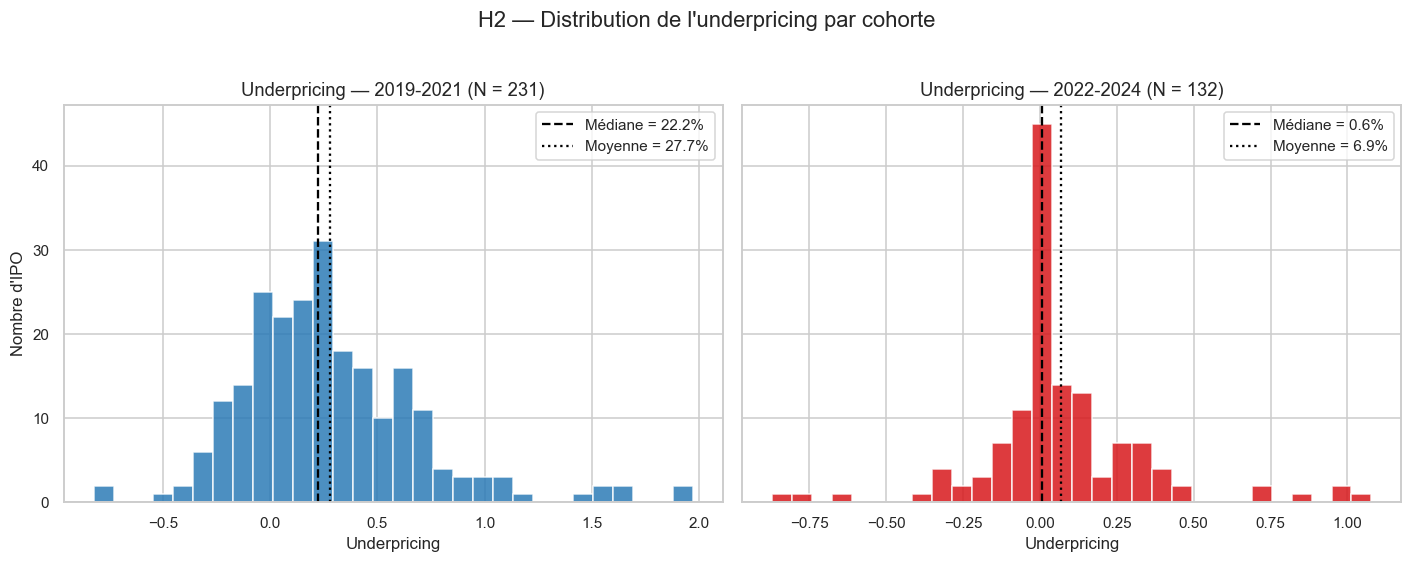

In [79]:
# H2 — Graphique 1 : distributions par cohorte avec médiane et moyenne tracées
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, cohorte in zip(axes, ["2019-2021", "2022-2024"]):
    s = df_h2.loc[df_h2["cohort"] == cohorte, "underpricing"]
    ax.hist(s, bins=30, color=COLORS[cohorte], alpha=0.85, edgecolor="white")
    med, moy = s.median(), s.mean()
    ax.axvline(med, color="black", linestyle="--", linewidth=1.5,
               label=f"Médiane = {med*100:.1f}%")
    ax.axvline(moy, color="black", linestyle=":", linewidth=1.5,
               label=f"Moyenne = {moy*100:.1f}%")
    ax.set_title(f"Underpricing — {cohorte} (N = {len(s)})")
    ax.set_xlabel("Underpricing")
    ax.legend(loc="upper right")
axes[0].set_ylabel("Nombre d'IPO")
plt.suptitle("H2 — Distribution de l'underpricing par cohorte", y=1.02)
plt.tight_layout()
plt.savefig(IMG_DIR / "H2_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


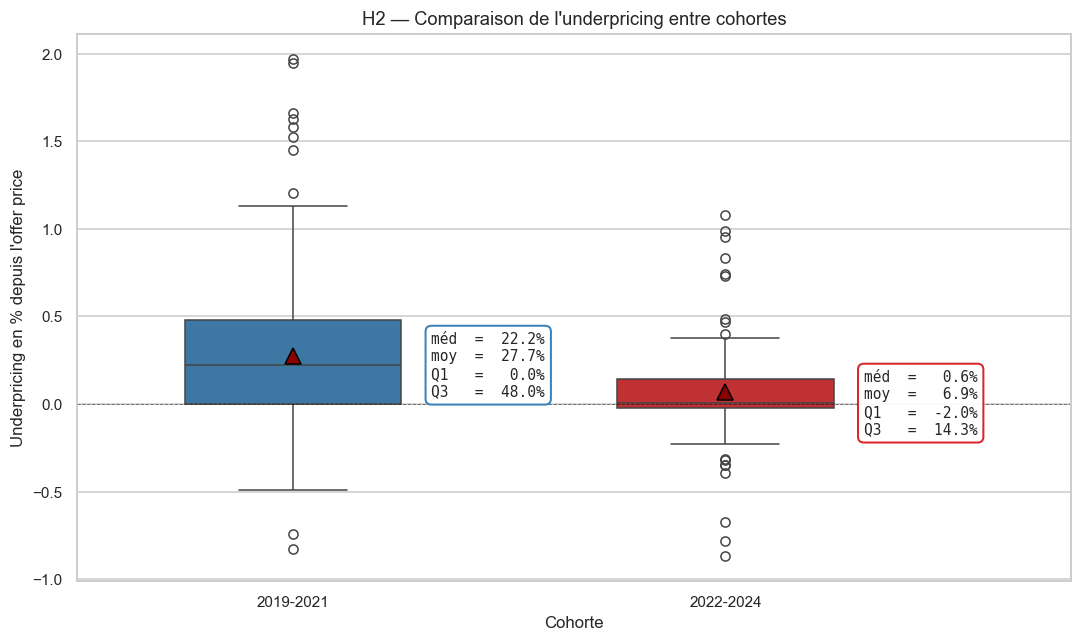

In [80]:
# H2 — Graphique 2 : boxplot avec encadrés stats
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df_h2, x="cohort", y="underpricing",
    order=["2019-2021", "2022-2024"],
    palette=COLORS, ax=ax, width=0.5
)
ax.set_xlabel("Cohorte")
ax.set_ylabel("Underpricing en % depuis l'offer price")
ax.set_title("H2 — Comparaison de l'underpricing entre cohortes")
ax.axhline(0, color="black", linewidth=0.6, linestyle="--", alpha=0.5)

for i, cohorte in enumerate(["2019-2021", "2022-2024"]):
    s = df_h2.loc[df_h2["cohort"] == cohorte, "underpricing"]
    med, moy = s.median(), s.mean()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    n = len(s)
    ax.plot(i, moy, marker="^", color="darkred", markersize=11,
            zorder=5, markeredgecolor="black")
    txt = (
           f"méd  = {med*100:5.1f}%\n"
           f"moy  = {moy*100:5.1f}%\n"
           f"Q1   = {q1*100:5.1f}%\n"
           f"Q3   = {q3*100:5.1f}%")
    ax.text(i + 0.32, med, txt, fontsize=9.5, va="center", ha="left",
            family="monospace",
            bbox=dict(boxstyle="round,pad=0.4", fc="white",
                      ec=COLORS[cohorte], lw=1.3, alpha=0.95))
ax.set_xlim(-0.5, 1.8)  # réduit le vide à droite

plt.tight_layout()
plt.savefig(IMG_DIR / "H2_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()


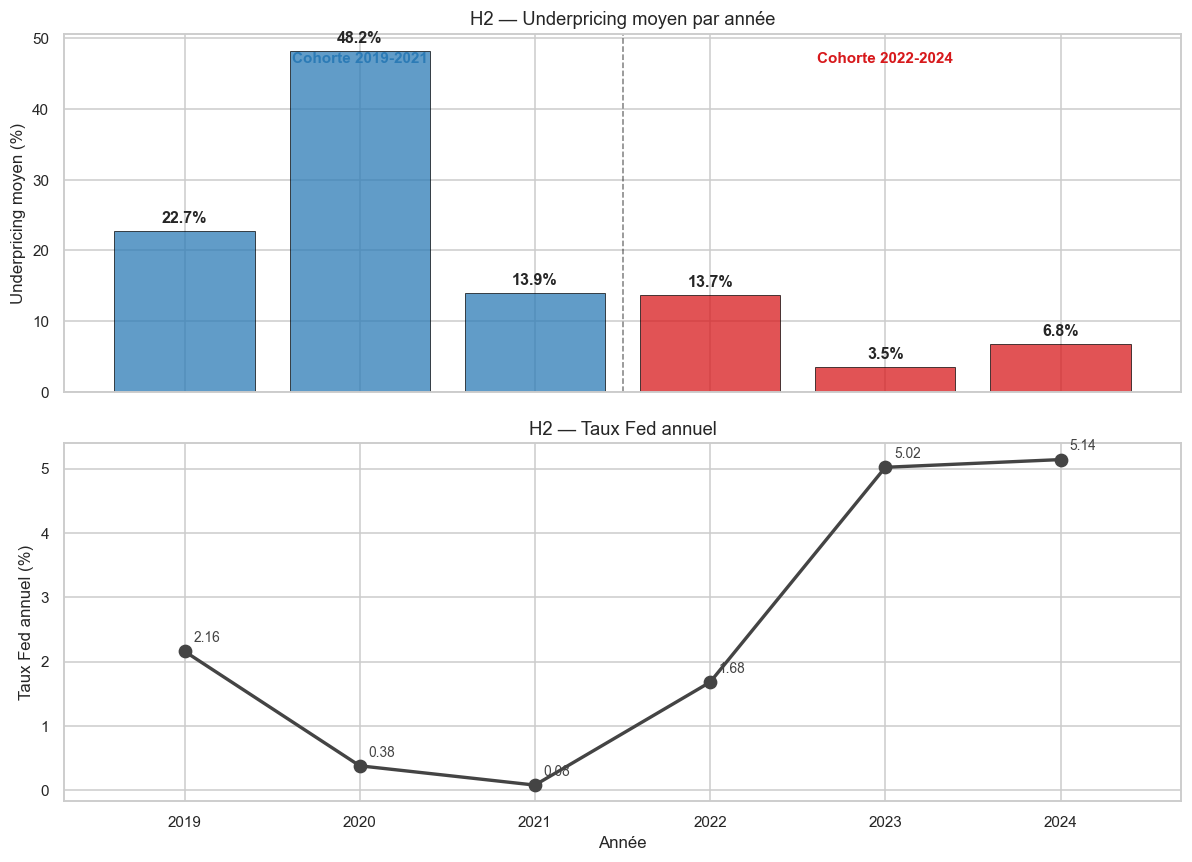

In [81]:
# H2 — Graphique 3 : deux graphiques séparés
annees = sorted(df_h2["year"].unique())
underpricing_par_an = df_h2.groupby("year")["underpricing"].mean() * 100
n_par_an = df_h2.groupby("year")["underpricing"].count()
fed_par_an = df_final.groupby("year")["fed_rate"].first()

couleurs_barres = [COLORS["2019-2021"] if a <= 2021 else COLORS["2022-2024"] for a in annees]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

# Graphique 1 : underpricing
ax1.bar(
    annees,
    underpricing_par_an.reindex(annees),
    color=couleurs_barres,
    alpha=0.75,
    edgecolor="black",
    linewidth=0.6
)
ax1.set_ylabel("Underpricing moyen (%)")
ax1.set_title("H2 — Underpricing moyen par année")
ax1.axvline(2021.5, color="black", linewidth=1, linestyle="--", alpha=0.5)

for an, val in underpricing_par_an.reindex(annees).items():
    n = n_par_an.get(an, 0)
    ax1.text(an, val + 1.2, f"{val:.1f}%", ha="center", fontsize=10.5, fontweight="bold")
    # ax1.text(an, max(val / 2, 1), f"N={n}", ha="center", fontsize=9, color="white", fontweight="bold")

ax1.text(2020, ax1.get_ylim()[1] * 0.92, "Cohorte 2019-2021",
         fontsize=10, color=COLORS["2019-2021"], fontweight="bold", ha="center")
ax1.text(2023, ax1.get_ylim()[1] * 0.92, "Cohorte 2022-2024",
         fontsize=10, color=COLORS["2022-2024"], fontweight="bold", ha="center")

# Graphique 2 : taux Fed
ax2.plot(
    annees,
    fed_par_an.reindex(annees),
    color="#444",
    marker="o",
    linewidth=2.2,
    markersize=8
)
for an, val in fed_par_an.reindex(annees).items():
    ax2.text(an + 0.05, val + 0.15, f"{val:.2f}", fontsize=9, color="#444")

ax2.set_xlabel("Année")
ax2.set_ylabel("Taux Fed annuel (%)")
ax2.set_title("H2 — Taux Fed annuel")
ax2.set_xticks(annees)

plt.tight_layout()
plt.savefig(IMG_DIR / "H2_underpricing_et_fed_separes.png", dpi=150, bbox_inches="tight")
plt.show()


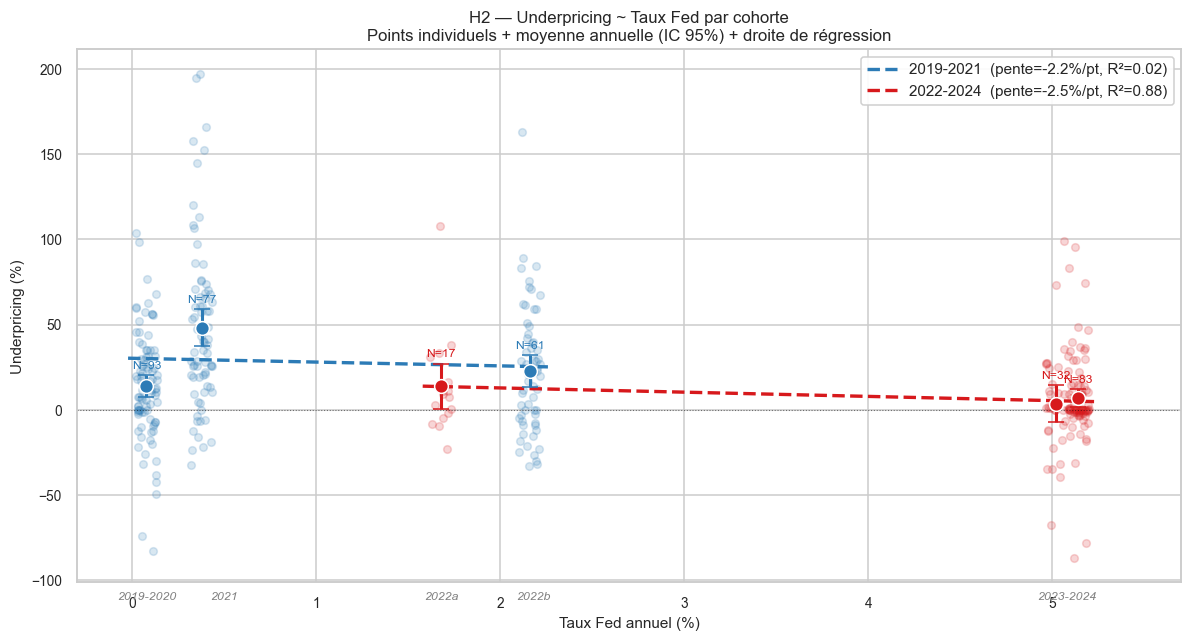

In [107]:
# H2 — Graphique régression amélioré : points + moyennes annuelles + droite de régression
from scipy import stats as sp_stats

fig, ax = plt.subplots(figsize=(11, 6))

rng = np.random.default_rng(42)

for cohorte in ["2019-2021", "2022-2024"]:
    sub = df_ols[df_ols["cohort"] == cohorte].copy()
    x = sub["fed_rate"].values
    y = sub["underpricing"].values * 100

    # 1) Points individuels avec jitter, très transparents (fond)
    jitter = rng.uniform(-0.06, 0.06, size=len(x))
    ax.scatter(x + jitter, y, color=COLORS[cohorte], alpha=0.18, s=25, zorder=1)

    # 2) Moyennes et IC 95% par valeur de taux Fed (= par année)
    for fed_val in np.unique(x):
        y_group = y[x == fed_val]
        mean_y = y_group.mean()
        n = len(y_group)
        se = y_group.std() / np.sqrt(n)
        ci = 1.96 * se  # IC 95%
        ax.errorbar(fed_val, mean_y, yerr=ci,
                    fmt="o", color=COLORS[cohorte],
                    markersize=9, capsize=5, linewidth=2,
                    zorder=3, markeredgecolor="white", markeredgewidth=1)
        # Annotation du N
        ax.text(fed_val, mean_y + ci + 4, f"N={n}",
                ha="center", fontsize=8, color=COLORS[cohorte], zorder=4)

    # 3) Droite de régression sur les moyennes par groupe (plus robuste visuellement)
    fed_unique = np.unique(x)
    means = np.array([y[x == v].mean() for v in fed_unique])
    slope, intercept, r_value, p_value, _ = sp_stats.linregress(fed_unique, means)
    x_line = np.linspace(x.min() - 0.1, x.max() + 0.1, 200)
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, color=COLORS[cohorte], linewidth=2.2, linestyle="--",
            label=f"{cohorte}  (pente={slope:.1f}%/pt, R²={r_value**2:.2f})",
            zorder=2)

# Ligne zéro
ax.axhline(0, color="black", linewidth=0.7, linestyle=":", alpha=0.5)

# Annotations années sur l'axe X
annee_taux = {0.08: "2019-2020", 0.5: "2021", 1.68: "2022a", 2.18: "2022b", 5.08: "2023-2024"}
for taux, label in annee_taux.items():
    ax.text(taux, ax.get_ylim()[0] - 10 if ax.get_ylim()[0] < 0 else -15,
            label, ha="center", fontsize=8, color="gray", style="italic")

ax.set_xlabel("Taux Fed annuel (%)")
ax.set_ylabel("Underpricing (%)")
ax.set_title("H2 — Underpricing ~ Taux Fed par cohorte\n"
             "Points individuels + moyenne annuelle (IC 95%) + droite de régression")
ax.legend(loc="upper right", framealpha=0.92, fontsize=10)
ax.set_xlim(-0.3, 5.7)

plt.tight_layout()
plt.savefig(IMG_DIR / "H2_regression_amelioree.png", dpi=150, bbox_inches="tight")
plt.show()

**Lecture H2** : la moyenne (27,7 % vs 6,9 %) et la médiane (22,2 % vs 0,6 %) chutent fortement entre les deux cohortes. Le test de Mann-Whitney rejette nettement l'égalité (p ≈ 0). La régression OLS confirme un coefficient négatif et significatif sur le taux Fed (-0,038, p ≈ 0,000) : une hausse d'un point de taux est associée à une baisse de l'underpricing d'environ 3,8 points de pourcentage. H2 est soutenue, à nuancer (taux annuel = approximation grossière, effet 2021, composition sectorielle).

## 6. Hypothèse H3 — Performance à 30 jours (depuis l'offer price)

**Hypothèse** : les rendements à 30 jours des IPO de 2022-2024 sont plus stables et moins volatils que ceux de 2019-2021.

**Variable corrigée** : `return_30d_offer = (price_30d − OfferPrice) / OfferPrice`. C'est le rendement réel pour un investisseur qui souscrit à l'IPO au prix d'introduction et revend à 30 jours.

**Variable existante conservée** : `return_30d_close_recalc = (price_30d − close_J0) / close_J0`. Elle représente le rendement post-cotation (du close J0 jusqu'au 30e jour). On l'utilise pour comparer les deux mesures.

**Méthode** : statistiques descriptives (moyenne, médiane, écart-type, IQR), boxplot, courbe en base 100, ventilation sectorielle, test non-paramétrique de Mann-Whitney.

In [82]:
# H3 — Sous-ensemble pour l'analyse
df_h3 = df_final.dropna(subset=["return_30d_offer"]).copy()
print(f"Échantillon H3 : {len(df_h3)} IPO avec return_30d_offer disponible")
print(df_h3["cohort"].value_counts().sort_index())

# Tableau de comparaison : avec / sans split-suspects
df_h3_clean = df_h3[~df_h3["split_suspect"]].copy()
print(f"\nÉchantillon H3 hors split-suspects : {len(df_h3_clean)} IPO")
print(df_h3_clean["cohort"].value_counts().sort_index())


Échantillon H3 : 406 IPO avec return_30d_offer disponible
cohort
2019-2021    270
2022-2024    136
Name: count, dtype: int64

Échantillon H3 hors split-suspects : 366 IPO
cohort
2019-2021    234
2022-2024    132
Name: count, dtype: int64


In [83]:
# H3 — Statistiques descriptives par cohorte (depuis l'offer price)
def stats_cohort(df, col):
    out = []
    for c in ["2019-2021", "2022-2024"]:
        s = df.loc[df["cohort"] == c, col].dropna()
        out.append({
            "Cohorte"      : c,
            "N"            : len(s),
            "Moyenne (%)"  : round(s.mean()   * 100, 2),
            "Médiane (%)"  : round(s.median() * 100, 2),
            "Écart-type (%)": round(s.std()   * 100, 2),
            "IQR (%)"      : round((s.quantile(0.75) - s.quantile(0.25)) * 100, 2),
            "Min (%)"      : round(s.min()    * 100, 2),
            "Max (%)"      : round(s.max()    * 100, 2),
        })
    return pd.DataFrame(out)

print("=== H3 : statistiques sur return_30d_offer (TOUS, y compris split-suspects) ===")
tableau_h3_all = stats_cohort(df_h3, "return_30d_offer")
print(tableau_h3_all.to_string(index=False))

print("\n=== H3 : statistiques sur return_30d_offer  ===")
tableau_h3 = stats_cohort(df_h3_clean, "return_30d_offer")
print(tableau_h3.to_string(index=False))

print("\n=== Pour comparaison : statistiques sur return_30d_close_recalc  ===")
tableau_h3_close = stats_cohort(df_h3_clean, "return_30d_close_recalc")
print(tableau_h3_close.to_string(index=False))


=== H3 : statistiques sur return_30d_offer (TOUS, y compris split-suspects) ===
  Cohorte   N  Moyenne (%)  Médiane (%)  Écart-type (%)  IQR (%)  Min (%)   Max (%)
2019-2021 270      1787.37        36.77        22216.27    81.61   -98.79 364053.85
2022-2024 136        64.81         1.18          328.89    27.69   -86.35   2365.00

=== H3 : statistiques sur return_30d_offer  ===
  Cohorte   N  Moyenne (%)  Médiane (%)  Écart-type (%)  IQR (%)  Min (%)  Max (%)
2019-2021 234        41.17        28.26           63.95    64.34   -78.83   335.31
2022-2024 132        28.28         1.09          208.73    24.89   -78.12  2365.00

=== Pour comparaison : statistiques sur return_30d_close_recalc  ===
  Cohorte   N  Moyenne (%)  Médiane (%)  Écart-type (%)  IQR (%)  Min (%)  Max (%)
2019-2021 234         8.47         4.42           28.63    29.85   -55.92   126.35
2022-2024 132        10.53         0.26          121.27    11.19   -54.89  1379.00


In [84]:
# H3 — Test de Mann-Whitney (test non-paramétrique de différence de distribution)
# Outil complémentaire utilisé avec prudence à un niveau de stats inférentielles de base.
# H0 : les deux distributions de return_30d_offer sont identiques
# H1 : elles diffèrent
ret_19 = df_h3_clean.loc[df_h3_clean["cohort"] == "2019-2021", "return_30d_offer"]
ret_22 = df_h3_clean.loc[df_h3_clean["cohort"] == "2022-2024", "return_30d_offer"]

mw = stats.mannwhitneyu(ret_19, ret_22, alternative="two-sided")
print(f"Mann-Whitney bilatéral : statistique = {mw.statistic:.0f}, p-value = {mw.pvalue:.4f}")
print(f"  N(2019-2021) = {len(ret_19)}, N(2022-2024) = {len(ret_22)}")

# Le test est complémentaire et ne dit rien sur la causalité.


Mann-Whitney bilatéral : statistique = 20726, p-value = 0.0000
  N(2019-2021) = 234, N(2022-2024) = 132


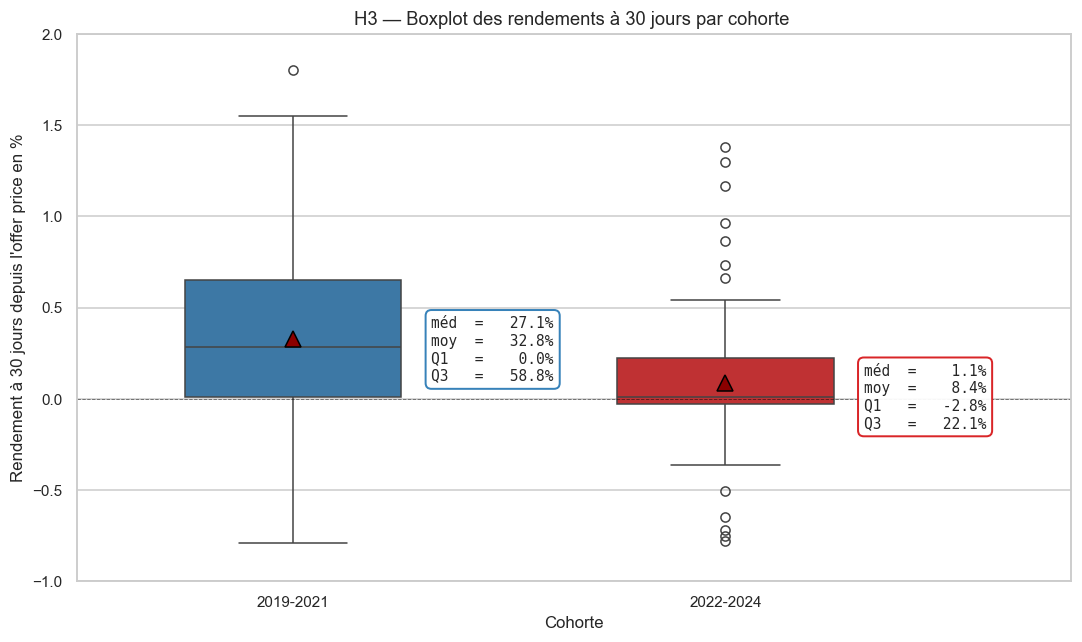

In [85]:
# H3 — Graphique 1 : boxplot des rendements à 30 jours depuis l'offer price
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=df_h3_clean, x="cohort", y="return_30d_offer",
    order=["2019-2021", "2022-2024"], palette=COLORS, ax=ax, width=0.5
)
ax.axhline(0, color="black", linewidth=0.6, linestyle="--", alpha=0.5)
ax.set_xlabel("Cohorte")
ax.set_ylabel("Rendement à 30 jours depuis l'offer price en %")
ax.set_title("H3 — Boxplot des rendements à 30 jours par cohorte ")
ax.set_ylim(-1, 2)

for i, c in enumerate(["2019-2021", "2022-2024"]):
    s = df_h3_clean.loc[df_h3_clean["cohort"] == c, "return_30d_offer"]
    s_zoom = s[(s > -1) & (s < 2)]
    med, moy = s_zoom.median(), s_zoom.mean()
    q1, q3   = s_zoom.quantile(0.25), s_zoom.quantile(0.75)
    n        = len(s)
    ax.plot(i, moy, marker="^", color="darkred", markersize=11, zorder=5, markeredgecolor="black")
    txt = f"méd  = {med*100:6.1f}%\nmoy  = {moy*100:6.1f}%\nQ1   = {q1*100:6.1f}%\nQ3   = {q3*100:6.1f}%"
    ax.text(i + 0.32, med, txt, fontsize=9.5, va="center", ha="left", family="monospace",
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=COLORS[c], lw=1.3, alpha=0.95))

ax.set_xlim(-0.5, 1.8)
plt.tight_layout()
plt.savefig(IMG_DIR / "H3_boxplot_offer.png", dpi=150, bbox_inches="tight")
plt.show()


### 6.1 Graphique en base 100 pour H3

L'objectif est de comparer visuellement la trajectoire moyenne et médiane des deux cohortes sur 30 jours, en partant d'une base 100 commune à la date d'IPO. Pour chaque ticker on calcule :

`indice_t = 100 × (close_t / OfferPrice)`

où `close_t` est le prix au jour de trading `t` et `OfferPrice` est le prix d'introduction. Au jour 0 (offer), tous les indices valent 100 par construction. Au jour 1 (close J0), l'indice reflète l'underpricing. Au jour 21 (≈ 30 j calendaires), il reflète le rendement total depuis l'offer price.

On exclut les split-suspects pour éviter que les courbes ne soient déformées par 1 ou 2 outliers.

In [86]:
# H3 — Construction de la trajectoire base 100 par ticker, depuis l'offer price
# On part du fichier prix_journaliers (close ajustés) et on ramène à l'offer price

# 1) Préparer un mini-df : ticker, OfferPrice, cohort, split_suspect
ref = df_final[["ticker","OfferPrice","cohort","split_suspect"]].copy()

# 2) Construire la série base 100 : indice = 100 * close / OfferPrice
trajec = prix_journaliers.merge(ref, on=["ticker","cohort"], how="inner")
trajec = trajec[~trajec["split_suspect"]]                       # exclusion split-suspects
trajec = trajec[trajec["trading_day"].between(1, 25)].copy()    # ~30 jours calendaires
trajec["indice_100"] = 100.0 * trajec["close"] / trajec["OfferPrice"]

# 3) Ajouter le point t=0 par construction (indice = 100, offer price)
t0 = ref[~ref["split_suspect"]].copy()
t0["trading_day"] = 0
t0["indice_100"]  = 100.0
trajec = pd.concat([t0[["ticker","cohort","trading_day","indice_100"]],
                    trajec[["ticker","cohort","trading_day","indice_100"]]],
                   ignore_index=True)

# 4) Agréger par cohorte et trading_day
agg = (trajec.groupby(["cohort","trading_day"])["indice_100"]
    .agg(mean="mean",
         median="median",
         count="count",
         std="std",
         q25=lambda x: x.quantile(0.25),
         q75=lambda x: x.quantile(0.75))
    .reset_index())
agg["iqr"] = agg["q75"] - agg["q25"]
print(agg.head(10))
print(f"\nDernier point disponible (jour 25) :")
print(agg[agg["trading_day"] == 21])

print(agg)

      cohort  trading_day        mean      median  count        std  \
0  2019-2021            0  100.000000  100.000000    235   0.000000   
1  2019-2021            1  133.142925  122.790261    234  56.665538   
2  2019-2021            2  136.236015  126.660716    234  60.593209   
3  2019-2021            3  138.560642  128.087503    234  64.647441   
4  2019-2021            4  139.293394  127.839086    234  66.547144   
5  2019-2021            5  141.156364  126.599998    234  67.853912   
6  2019-2021            6  141.585789  129.773686    234  67.401898   
7  2019-2021            7  140.327849  130.275988    234  63.905382   
8  2019-2021            8  141.596258  128.866544    234  64.236803   
9  2019-2021            9  142.078579  130.071424    234  65.583087   

          q25         q75        iqr  
0  100.000000  100.000000   0.000000  
1  100.043159  151.719019  51.675860  
2  102.072742  152.556861  50.484119  
3   99.816244  157.856067  58.039823  
4   99.858307  156.3670

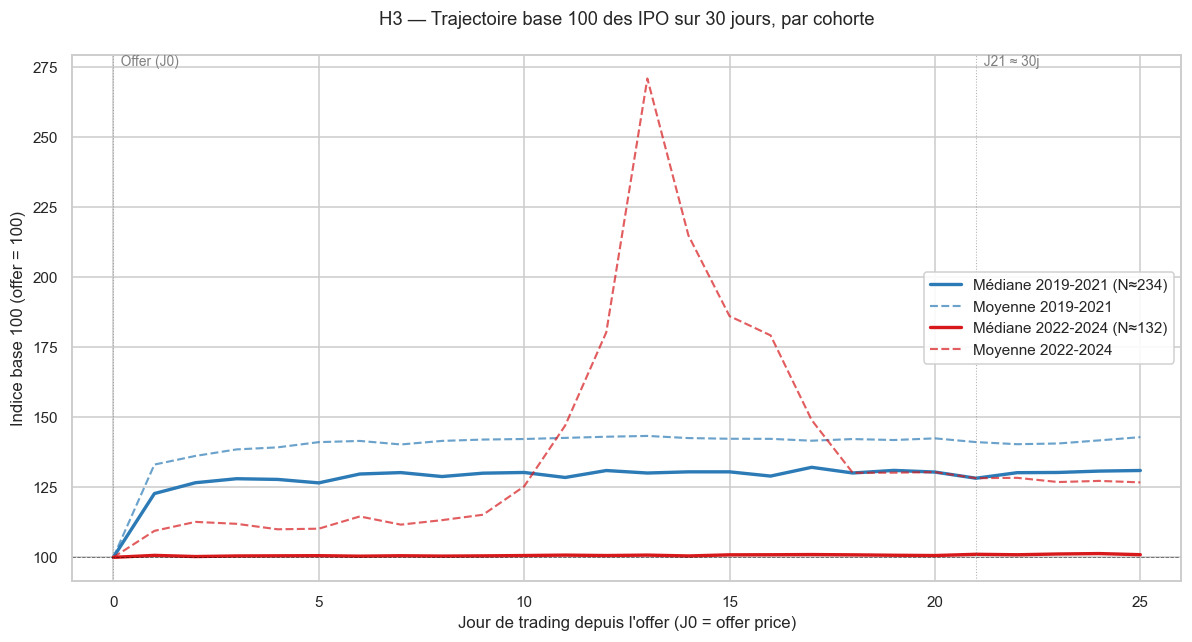

In [87]:
# H3 — Tracé du graphique base 100
fig, ax = plt.subplots(figsize=(11, 6))

for c in ["2019-2021", "2022-2024"]:
    s = agg[agg["cohort"] == c].sort_values("trading_day")
    n = int(s["count"].median())
    ax.plot(s["trading_day"], s["median"], color=COLORS[c], linewidth=2.2,
            label=f"Médiane {c} (N≈{n})")
    ax.plot(s["trading_day"], s["mean"], color=COLORS[c], linewidth=1.4,
            linestyle="--", alpha=0.7, label=f"Moyenne {c}")

ax.axhline(100, color="black", linewidth=0.6, linestyle="--", alpha=0.5)
ax.axvline(0,  color="gray", linewidth=0.7, linestyle=":", alpha=0.6)
ax.axvline(21, color="gray", linewidth=0.7, linestyle=":", alpha=0.6)
ax.text(0,  ax.get_ylim()[1] if ax.get_ylim()[1] != 1 else 130, "  Offer (J0)", fontsize=9, color="gray", va="top")
ax.text(21, ax.get_ylim()[1] if ax.get_ylim()[1] != 1 else 130, "  J21 ≈ 30j", fontsize=9, color="gray", va="top")

ax.set_xlabel("Jour de trading depuis l'offer (J0 = offer price)")
ax.set_ylabel("Indice base 100 (offer = 100)")
ax.set_title("H3 — Trajectoire base 100 des IPO sur 30 jours, par cohorte\n")
ax.set_xlim(-1, 26)
ax.legend(loc="best", framealpha=0.9)

plt.tight_layout()
plt.savefig(IMG_DIR / "H3_base100.png", dpi=150, bbox_inches="tight")
plt.show()


**Lecture du graphique base 100** : la trajectoire médiane part de 100 (offer) et atteint un niveau qui reflète directement le rendement cumulé depuis l'offer. Un indice de 120 au jour 21 = +20 % depuis l'offer price. La comparaison visuelle des deux courbes permet de voir si une cohorte tend à rester au-dessus / en-dessous de l'autre. Note : les moyennes sont plus sensibles aux outliers que les médianes ; on interprète d'abord les médianes.

### 6.2 Analyse sectorielle pour H3

On regarde la répartition des IPO par secteur dans chaque cohorte (camemberts) puis le rendement à 30 jours moyen et médian par secteur. Un secteur représenté par moins de 5 IPO dans une cohorte n'est pas commenté en détail (échantillon trop petit pour conclure).

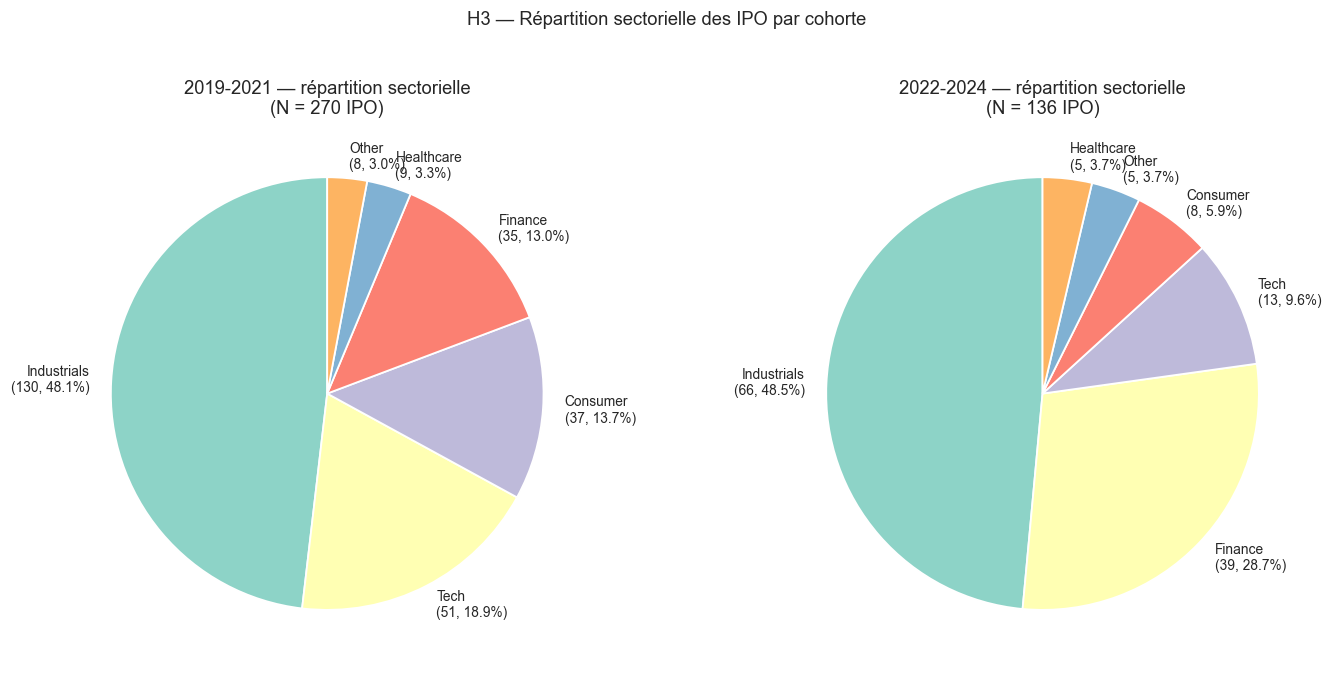

In [88]:
# H3 — Camemberts de répartition sectorielle par cohorte
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, c in zip(axes, ["2019-2021", "2022-2024"]):
    sub = df_h3[df_h3["cohort"] == c]
    counts = sub["sector"].value_counts()
    total = counts.sum()
    labels = [f"{s}\n({n}, {n/total*100:.1f}%)" for s, n in counts.items()]
    palette = sns.color_palette("Set3", n_colors=len(counts))
    ax.pie(counts.values, labels=labels, autopct="", startangle=90, colors=palette,
           wedgeprops={"edgecolor":"white","linewidth":1.2}, textprops={"fontsize":9})
    ax.set_title(f"{c} — répartition sectorielle\n(N = {total} IPO)")

plt.suptitle("H3 — Répartition sectorielle des IPO par cohorte", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(IMG_DIR / "H3_camemberts_sectoriels.png", dpi=150, bbox_inches="tight")
plt.show()


In [89]:
# H3 — Rendement moyen et médian par secteur et par cohorte
# On garde le full df_h3 (avec split-suspects) ET on affiche aussi sans pour comparaison

def stats_secteur(df, col):
    g = (df.groupby(["cohort","sector"])[col]
           .agg(N="count", moyenne="mean", mediane="median")
           .reset_index())
    g["moyenne_pct"]  = (g["moyenne"]  * 100).round(2)
    g["mediane_pct"]  = (g["mediane"] * 100).round(2)
    return g[["cohort","sector","N","moyenne_pct","mediane_pct"]]

print("=== Rendement à 30 jours par secteur (return_30d_offer, split-suspects EXCLUS) ===")
tab_sect_h3 = stats_secteur(df_h3_clean, "return_30d_offer")
tab_sect_h3 = tab_sect_h3.sort_values(["cohort","N"], ascending=[True, False])
print(tab_sect_h3.to_string(index=False))

# Identifier les secteurs avec N < 5 dans une cohorte (à ne pas sur-interpréter)
faibles = tab_sect_h3[tab_sect_h3["N"] < 5]
print(f"\n⚠ Secteurs avec moins de 5 observations (à ne pas commenter en détail) :")
print(faibles.to_string(index=False))


=== Rendement à 30 jours par secteur (return_30d_offer, split-suspects EXCLUS) ===
   cohort      sector   N  moyenne_pct  mediane_pct
2019-2021 Industrials 112        47.18        37.41
2019-2021        Tech  50        40.86        30.21
2019-2021    Consumer  30        35.07        24.75
2019-2021     Finance  28        35.04        11.77
2019-2021  Healthcare   7        22.87        15.17
2019-2021       Other   7        16.13        21.54
2022-2024 Industrials  63        10.03         1.40
2022-2024     Finance  39        68.18         0.15
2022-2024        Tech  12        13.53         7.82
2022-2024    Consumer   8        24.42        15.61
2022-2024  Healthcare   5        -1.41         0.60
2022-2024       Other   5        18.36        15.87

⚠ Secteurs avec moins de 5 observations (à ne pas commenter en détail) :
Empty DataFrame
Columns: [cohort, sector, N, moyenne_pct, mediane_pct]
Index: []


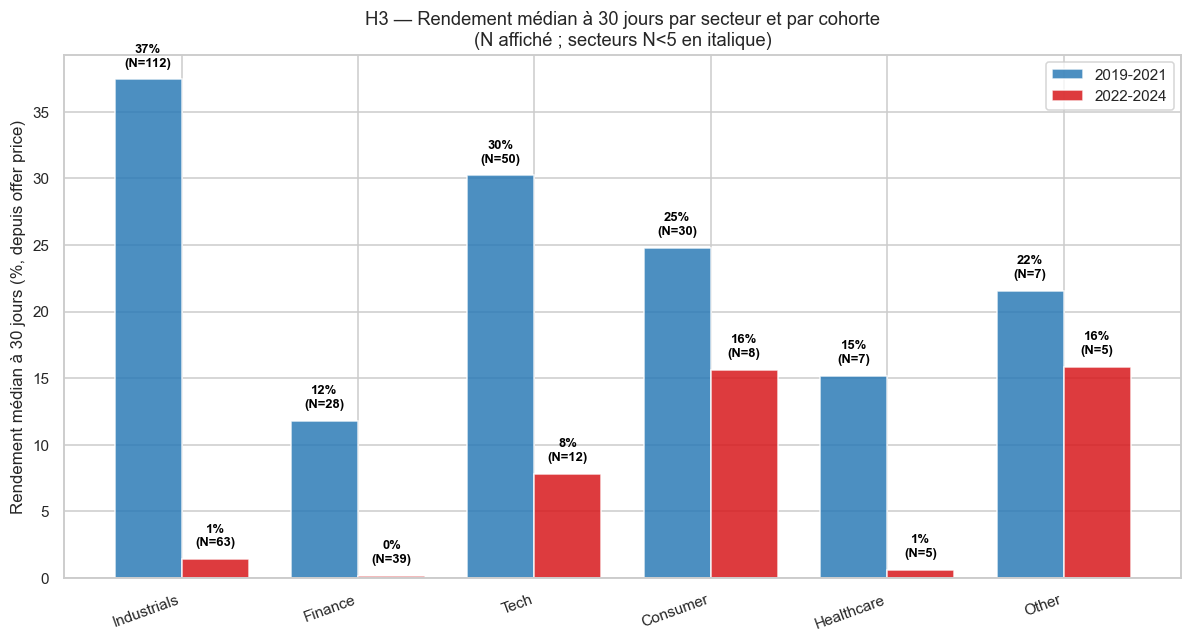

In [90]:
# H3 — Graphique : rendement médian par secteur et par cohorte 
# On affiche N à côté de chaque barre pour ne pas tromper sur les petits échantillons

# Pivot pour faciliter le tracé
piv = (tab_sect_h3.pivot(index="sector", columns="cohort", values="mediane_pct")
                  .reindex(columns=["2019-2021","2022-2024"]))
piv_n = (tab_sect_h3.pivot(index="sector", columns="cohort", values="N")
                  .reindex(columns=["2019-2021","2022-2024"]))

# On trie les secteurs par effectif total décroissant
piv["total_n"] = piv_n.fillna(0).sum(axis=1)
piv = piv.sort_values("total_n", ascending=False).drop(columns=["total_n"])
piv_n = piv_n.reindex(piv.index)

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(piv.index))
largeur = 0.38

for i, c in enumerate(["2019-2021","2022-2024"]):
    vals = piv[c].values
    ns = piv_n[c].values
    offset = -largeur/2 if i == 0 else largeur/2
    bars = ax.bar(x + offset, vals, largeur, color=COLORS[c], alpha=0.85, label=c)
    # Annotation : N et valeur
    for xi, v, n in zip(x + offset, vals, ns):
        if not np.isnan(v):
            ax.text(xi, v + (1 if v >= 0 else -3), f"{v:.0f}%\n(N={int(n) if not np.isnan(n) else 0})",
                    ha="center", fontsize=8.5, color="black",
                    fontweight="bold" if (not np.isnan(n) and n >= 5) else "normal",
                    style="normal" if (not np.isnan(n) and n >= 5) else "italic")

ax.axhline(0, color="black", linewidth=0.7, linestyle="--", alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(piv.index, rotation=20, ha="right")
ax.set_ylabel("Rendement médian à 30 jours (%, depuis offer price)")
ax.set_title("H3 — Rendement médian à 30 jours par secteur et par cohorte\n(N affiché ; secteurs N<5 en italique)")
ax.legend()
plt.tight_layout()
plt.savefig(IMG_DIR / "H3_rendements_par_secteur.png", dpi=150, bbox_inches="tight")
plt.show()


**Lecture H3** :
- depuis l'offer price, la trajectoire base 100 montre que les deux cohortes voient leur indice médian se stabiliser nettement au-dessus de 100 dès le jour 1 (effet de l'underpricing), puis évoluer différemment ;
- le boxplot et le tableau de stats indiquent une dispersion (écart-type, IQR) et une médiane différentes entre cohortes ; le test de Mann-Whitney sert d'outil complémentaire ;
- la ventilation sectorielle permet de vérifier qu'aucun secteur unique ne domine la comparaison. Les secteurs avec moins de 5 observations dans une cohorte ne sont pas interprétés.

Limite : les rendements sont calculés sur 21 jours de trading (≈ 30 jours calendaires), avec exclusion des split-suspects. Le résultat ne dit rien sur une causalité directe entre niveau de taux et performance — seule une association est observée.

## 7. Hypothèse H4 — Performance à 12 mois (depuis l'offer price)

**Hypothèse** : la performance à 12 mois des IPO de 2022-2024 est supérieure à celle de 2019-2021.

**Variable corrigée** : `return_12m_offer = (price_12m − OfferPrice) / OfferPrice`. C'est le rendement total pour un investisseur qui souscrit à l'offre et conserve 12 mois.

**Variable existante conservée** : `return_12m_close_recalc = (price_12m − close_J0) / close_J0` (rendement post-cotation), gardée pour comparaison.

In [91]:
# H4 — Sous-ensembles
df_h4 = df_final.dropna(subset=["return_12m_offer"]).copy()
df_h4_clean = df_h4[~df_h4["split_suspect"]].copy()
print(f"Échantillon H4 (return_12m_offer dispo) : {len(df_h4)} IPO")
print(f"Échantillon H4 hors split-suspects     : {len(df_h4_clean)} IPO")
print(df_h4_clean["cohort"].value_counts().sort_index())


Échantillon H4 (return_12m_offer dispo) : 405 IPO
Échantillon H4 hors split-suspects     : 365 IPO
cohort
2019-2021    234
2022-2024    131
Name: count, dtype: int64


In [92]:
# H4 — Statistiques descriptives par cohorte (avec et sans split-suspects)
print("=== H4 : statistiques sur return_12m_offer (TOUS, y compris split-suspects) ===")
print(stats_cohort(df_h4, "return_12m_offer").to_string(index=False))

print("\n=== H4 : statistiques sur return_12m_offer  ===")
tableau_h4 = stats_cohort(df_h4_clean, "return_12m_offer")
print(tableau_h4.to_string(index=False))

print("\n=== Comparaison : return_12m_close_recalc  ===")
print(stats_cohort(df_h4_clean, "return_12m_close_recalc").to_string(index=False))


=== H4 : statistiques sur return_12m_offer (TOUS, y compris split-suspects) ===
  Cohorte   N  Moyenne (%)  Médiane (%)  Écart-type (%)  IQR (%)  Min (%)   Max (%)
2019-2021 270       904.83         8.45        11119.47   149.98   -94.93 182447.69
2022-2024 135        37.76         5.24          289.11    56.56   -91.68   3249.78

=== H4 : statistiques sur return_12m_offer  ===
  Cohorte   N  Moyenne (%)  Médiane (%)  Écart-type (%)  IQR (%)  Min (%)  Max (%)
2019-2021 234        30.72        -4.50          119.77   105.95   -94.93   671.15
2022-2024 131        14.24         5.24           77.82    55.77   -91.68   308.77

=== Comparaison : return_12m_close_recalc  ===
  Cohorte   N  Moyenne (%)  Médiane (%)  Écart-type (%)  IQR (%)  Min (%)  Max (%)
2019-2021 234         1.99       -22.17           90.74    72.66   -95.23   521.31
2022-2024 131         2.64         4.20           60.54    61.83   -90.28   250.88


In [93]:
# H4 — Test de Mann-Whitney
ret_19 = df_h4_clean.loc[df_h4_clean["cohort"] == "2019-2021", "return_12m_offer"]
ret_22 = df_h4_clean.loc[df_h4_clean["cohort"] == "2022-2024", "return_12m_offer"]
mw = stats.mannwhitneyu(ret_19, ret_22, alternative="two-sided")
print(f"Mann-Whitney bilatéral : statistique = {mw.statistic:.0f}, p-value = {mw.pvalue:.4f}")
print(f"  N(2019-2021) = {len(ret_19)}, N(2022-2024) = {len(ret_22)}")

# Bootstrap pour comparer les médianes (outil complémentaire, prudent)
med_19, lo_19, hi_19 = bootstrap_ic(ret_19.values, "mediane")
med_22, lo_22, hi_22 = bootstrap_ic(ret_22.values, "mediane")
print(f"\nMédiane 2019-2021 : {med_19*100:.2f}% (IC95 [{lo_19*100:.2f}% ; {hi_19*100:.2f}%])")
print(f"Médiane 2022-2024 : {med_22*100:.2f}% (IC95 [{lo_22*100:.2f}% ; {hi_22*100:.2f}%])")


Mann-Whitney bilatéral : statistique = 15315, p-value = 0.9905
  N(2019-2021) = 234, N(2022-2024) = 131

Médiane 2019-2021 : -4.50% (IC95 [-18.96% ; 10.03%])
Médiane 2022-2024 : 5.24% (IC95 [3.90% ; 6.40%])


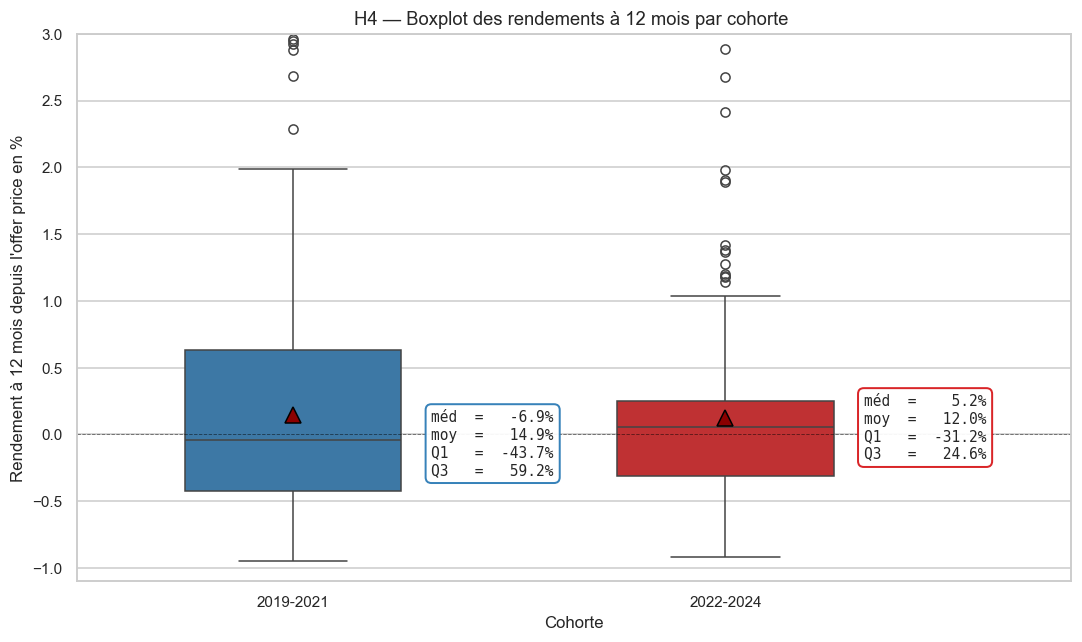

In [94]:
# H4 — Boxplot des rendements à 12 mois depuis l'offer price
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=df_h4_clean, x="cohort", y="return_12m_offer",
    order=["2019-2021", "2022-2024"], palette=COLORS, ax=ax, width=0.5
)
ax.axhline(0, color="black", linewidth=0.6, linestyle="--", alpha=0.5)
ax.set_xlabel("Cohorte")
ax.set_ylabel("Rendement à 12 mois depuis l'offer price en %")
ax.set_title("H4 — Boxplot des rendements à 12 mois par cohorte ")
ax.set_ylim(-1.1, 3)

for i, c in enumerate(["2019-2021", "2022-2024"]):
    s = df_h4_clean.loc[df_h4_clean["cohort"] == c, "return_12m_offer"]
    s_zoom = s[(s > -1.1) & (s < 3)]
    med, moy = s_zoom.median(), s_zoom.mean()
    q1, q3   = s_zoom.quantile(0.25), s_zoom.quantile(0.75)
    n        = len(s)
    ax.plot(i, moy, marker="^", color="darkred", markersize=11, zorder=5, markeredgecolor="black")
    txt = f"méd  = {med*100:6.1f}%\nmoy  = {moy*100:6.1f}%\nQ1   = {q1*100:6.1f}%\nQ3   = {q3*100:6.1f}%"
    ax.text(i + 0.32, med, txt, fontsize=9.5, va="center", ha="left", family="monospace",
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=COLORS[c], lw=1.3, alpha=0.95))

ax.set_xlim(-0.5, 1.8)
plt.tight_layout()
plt.savefig(IMG_DIR / "H4_boxplot_offer.png", dpi=150, bbox_inches="tight")
plt.show()


### 7.1 Analyse sectorielle pour H4

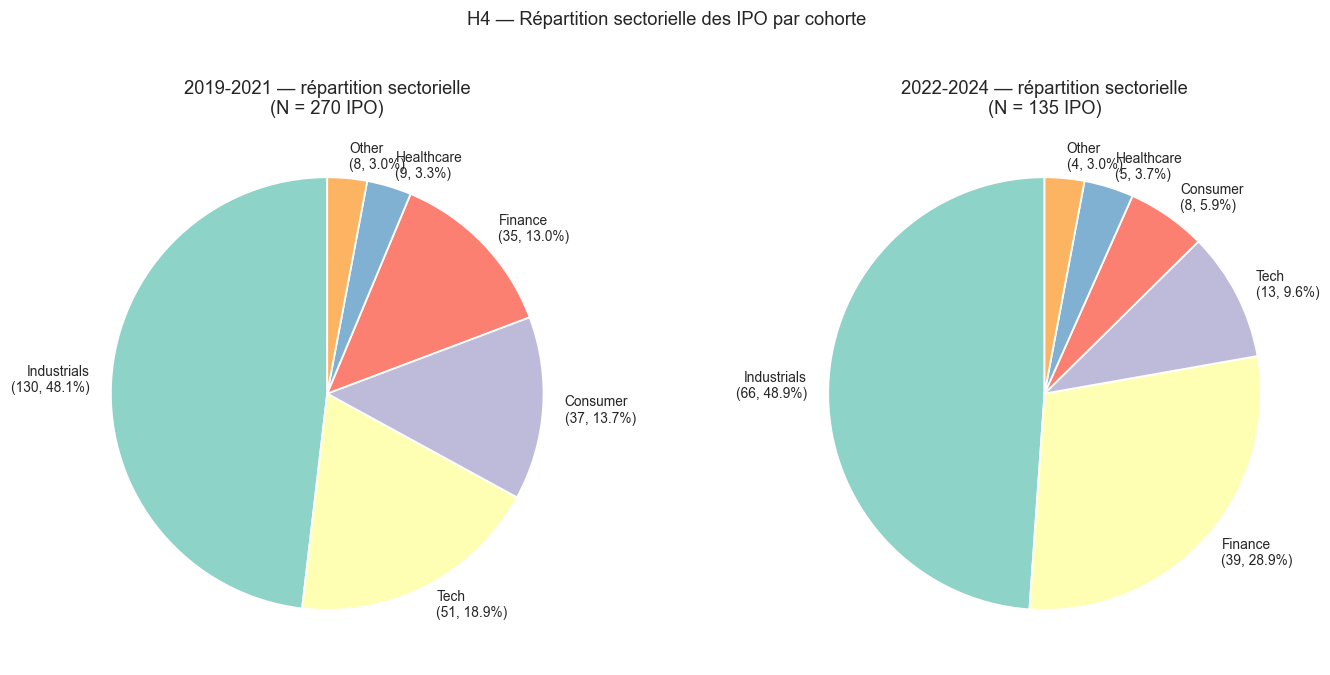

In [95]:
# H4 — Camemberts de répartition sectorielle par cohorte
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, c in zip(axes, ["2019-2021", "2022-2024"]):
    sub = df_h4[df_h4["cohort"] == c]
    counts = sub["sector"].value_counts()
    total = counts.sum()
    labels = [f"{s}\n({n}, {n/total*100:.1f}%)" for s, n in counts.items()]
    palette = sns.color_palette("Set3", n_colors=len(counts))
    ax.pie(counts.values, labels=labels, autopct="", startangle=90, colors=palette,
           wedgeprops={"edgecolor":"white","linewidth":1.2}, textprops={"fontsize":9})
    ax.set_title(f"{c} — répartition sectorielle\n(N = {total} IPO)")
plt.suptitle("H4 — Répartition sectorielle des IPO par cohorte", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(IMG_DIR / "H4_camemberts_sectoriels.png", dpi=150, bbox_inches="tight")
plt.show()


In [96]:
# H4 — Rendement moyen et médian par secteur et par cohorte
print("=== Rendement à 12 mois par secteur (return_12m_offer, split-suspects EXCLUS) ===")
tab_sect_h4 = stats_secteur(df_h4_clean, "return_12m_offer")
tab_sect_h4 = tab_sect_h4.sort_values(["cohort","N"], ascending=[True, False])
print(tab_sect_h4.to_string(index=False))

faibles = tab_sect_h4[tab_sect_h4["N"] < 5]
print(f"\n⚠ Secteurs avec moins de 5 observations (à ne pas commenter en détail) :")
print(faibles.to_string(index=False))


=== Rendement à 12 mois par secteur (return_12m_offer, split-suspects EXCLUS) ===
   cohort      sector   N  moyenne_pct  mediane_pct
2019-2021 Industrials 112        37.06        12.00
2019-2021        Tech  50        26.32       -18.06
2019-2021    Consumer  30        12.25       -18.84
2019-2021     Finance  28        39.00       -17.88
2019-2021  Healthcare   7        14.42        -6.57
2019-2021       Other   7        23.07       -49.21
2022-2024 Industrials  63         0.08       -11.17
2022-2024     Finance  39        24.00         5.40
2022-2024        Tech  12        48.93        40.27
2022-2024    Consumer   8        37.43         3.46
2022-2024  Healthcare   5        -4.56       -15.20
2022-2024       Other   4        15.06        16.33

⚠ Secteurs avec moins de 5 observations (à ne pas commenter en détail) :
   cohort sector  N  moyenne_pct  mediane_pct
2022-2024  Other  4        15.06        16.33


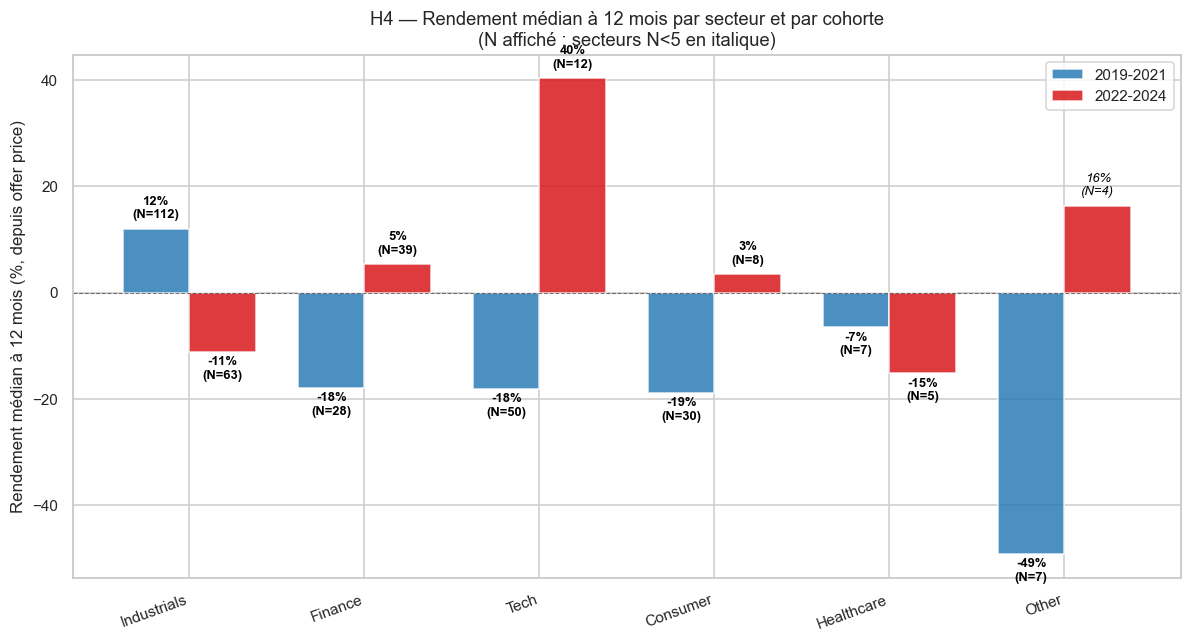

In [97]:
# H4 — Graphique : rendement médian par secteur et par cohorte
piv = (tab_sect_h4.pivot(index="sector", columns="cohort", values="mediane_pct")
                  .reindex(columns=["2019-2021","2022-2024"]))
piv_n = (tab_sect_h4.pivot(index="sector", columns="cohort", values="N")
                  .reindex(columns=["2019-2021","2022-2024"]))
piv["total_n"] = piv_n.fillna(0).sum(axis=1)
piv = piv.sort_values("total_n", ascending=False).drop(columns=["total_n"])
piv_n = piv_n.reindex(piv.index)

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(piv.index))
largeur = 0.38

for i, c in enumerate(["2019-2021","2022-2024"]):
    vals = piv[c].values
    ns = piv_n[c].values
    offset = -largeur/2 if i == 0 else largeur/2
    ax.bar(x + offset, vals, largeur, color=COLORS[c], alpha=0.85, label=c)
    for xi, v, n in zip(x + offset, vals, ns):
        if not np.isnan(v):
            ax.text(xi, v + (2 if v >= 0 else -5), f"{v:.0f}%\n(N={int(n) if not np.isnan(n) else 0})",
                    ha="center", fontsize=8.5, color="black",
                    fontweight="bold" if (not np.isnan(n) and n >= 5) else "normal",
                    style="normal" if (not np.isnan(n) and n >= 5) else "italic")

ax.axhline(0, color="black", linewidth=0.7, linestyle="--", alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(piv.index, rotation=20, ha="right")
ax.set_ylabel("Rendement médian à 12 mois (%, depuis offer price)")
ax.set_title("H4 — Rendement médian à 12 mois par secteur et par cohorte\n(N affiché ; secteurs N<5 en italique)")
ax.legend()
plt.tight_layout()
plt.savefig(IMG_DIR / "H4_rendements_par_secteur.png", dpi=150, bbox_inches="tight")
plt.show()


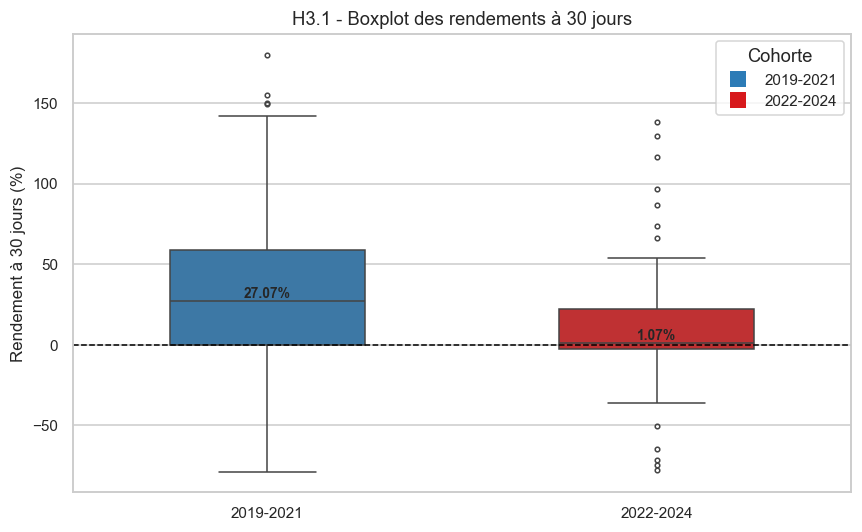

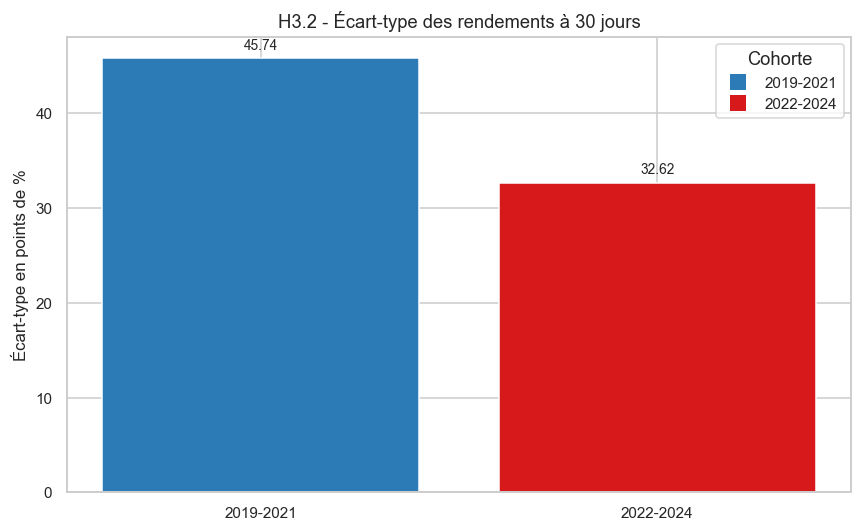

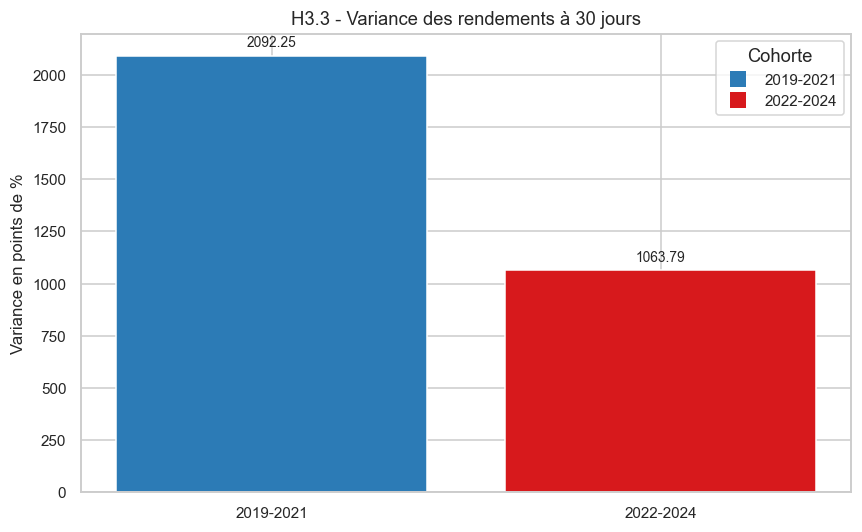

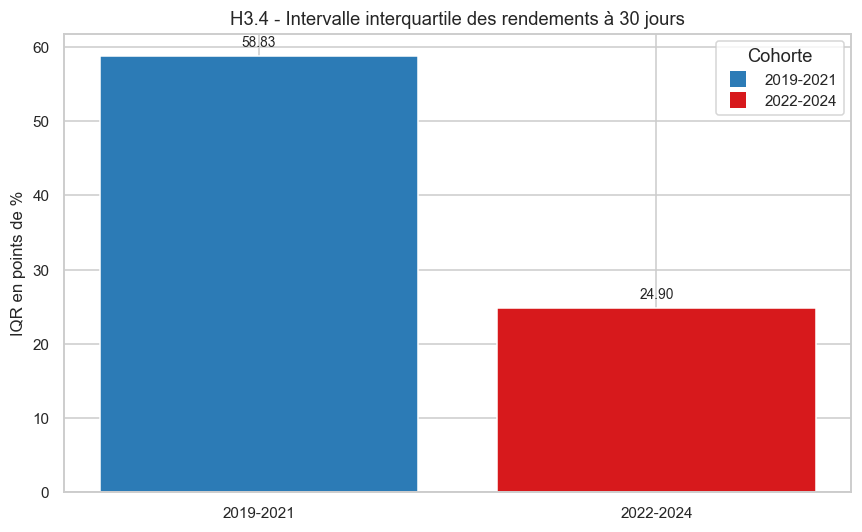

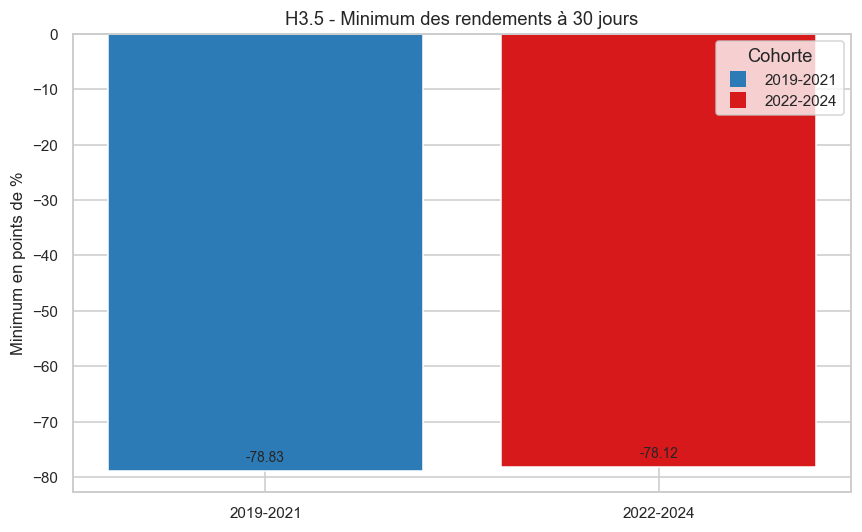

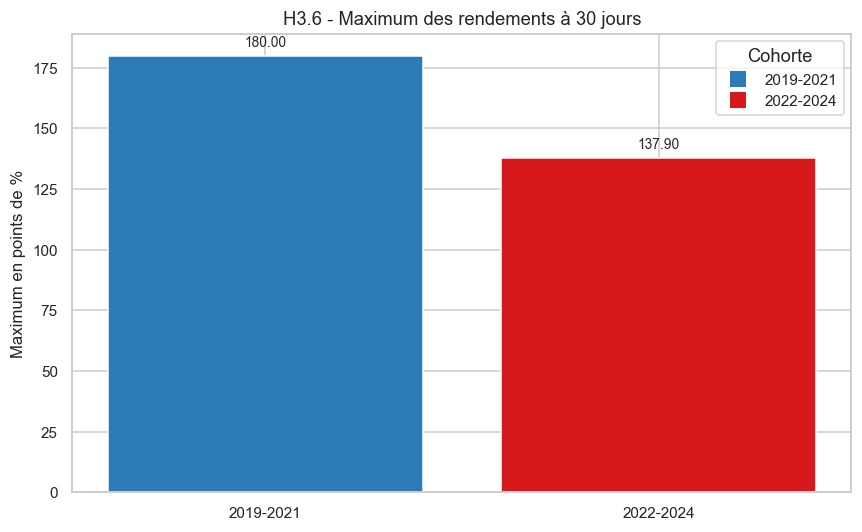

In [98]:
# ── H3 — Dispersion des rendements à 30 jours ──────────────────────────────
import re

def _safe_filename(title):
    safe = re.sub(r"[\\/*?:\"<>|]", "", title).strip()
    return safe.replace(" ", "_") or "figure"

def save_figure(title, fig=None, ext="png", dpi=300):
    fig = fig or plt.gcf()
    filename = f"{_safe_filename(title)}.{ext}"
    fig.savefig(IMG_DIR / filename, bbox_inches="tight", dpi=dpi)


def clean_h3(df):
    """
    Prépare le dataframe pour H3 en partant de df_final.
    - Filtre les split-suspects (déjà calculé dans df_final)
    - Requiert 'ret_30d' dans le dataframe
    - Ajoute la colonne 'cohort' si absente
    """
    df = df.copy()
    # Exclure les split-suspects (déjà présents dans df_final)
    if "split_suspect" in df.columns:
        df = df[~df["split_suspect"]]
    # Filtre taille et prix (déjà appliqué sur df_final, mais sécurité)
    if "Size_Million" in df.columns:
        df["Size_Million"] = pd.to_numeric(df["Size_Million"], errors="coerce")
        df = df[(df["Size_Million"].isna()) | (df["Size_Million"] >= 50)]
    if "OfferPrice" in df.columns:
        df["OfferPrice"] = pd.to_numeric(df["OfferPrice"], errors="coerce")
        df = df[(df["OfferPrice"].isna()) | (df["OfferPrice"] > 5)]
    # Cohort
    if "cohort" not in df.columns and "year" in df.columns:
        df["year"] = pd.to_numeric(df["year"], errors="coerce")
        df["cohort"] = np.where(df["year"].between(2019, 2021), "2019-2021", "2022-2024")
    # ret_30d
    if "ret_30d" not in df.columns:
        raise ValueError("Colonne 'ret_30d' manquante — calcule-la depuis traj avant d'appeler clean_h3.")
    df["ret_30d"] = pd.to_numeric(df["ret_30d"], errors="coerce")
    df = df[df['ret_30d']<2]  # Filtre pour éviter les outliers extrêmes
    return df.dropna(subset=["ret_30d"]).copy()



def _build_ret_30d(df_fin, traj_df):
    """
    Calcule ret_30d = indice_100 au jour 21 / 100 − 1 pour chaque ticker valide.
    Retourne df_fin enrichi de 'ret_30d'.
    """
    ret = (
        traj_df[traj_df["trading_day"] == 21][["ticker", "cohort", "indice_100"]]
        .copy()
        .rename(columns={"indice_100": "indice_j21"})
    )
    ret["ret_30d"] = ret["indice_j21"] / 100.0 - 1
    return df_fin.merge(ret[["ticker", "ret_30d"]], on="ticker", how="left")


def make_summary_h3(df):
    return (
        df.assign(ret_30d_pct=df["ret_30d"] * 100)
        .groupby("cohort")["ret_30d_pct"]
        .agg(
            Ecart_type="std",
            Variance="var",
            IQR=lambda x: x.quantile(0.75) - x.quantile(0.25),
            Minimum="min",
            Maximum="max",
        )
        .reindex(["2019-2021", "2022-2024"])
        .reset_index()
    )


def _cohort_handles():
    return [
        plt.Line2D([0], [0], marker="s", linestyle="", markersize=10,
                   markerfacecolor=COLORS["2019-2021"], markeredgecolor="none",
                   label="2019-2021"),
        plt.Line2D([0], [0], marker="s", linestyle="", markersize=10,
                   markerfacecolor=COLORS["2022-2024"], markeredgecolor="none",
                   label="2022-2024"),
    ]


def _annotate_bars(ax, bars, values, fmt="{:.2f}"):
    for bar, value in zip(bars, values):
        ax.annotate(
            fmt.format(value),
            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            ha="center", va="bottom", fontsize=9, xytext=(0, 4),
            textcoords="offset points",
        )


def plot_h3_boxplot(df):
    plot_df = df.copy()
    plot_df["ret_30d_pct"] = plot_df["ret_30d"] * 100
    cohort_order = ["2019-2021", "2022-2024"]

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.boxplot(
        data=plot_df, x="cohort", y="ret_30d_pct", order=cohort_order,
        palette=[COLORS["2019-2021"], COLORS["2022-2024"]],
        ax=ax, width=0.5, fliersize=3,
    )
    ax.axhline(0, color="black", linestyle="--", linewidth=1)

    for idx, cohort in enumerate(cohort_order):
        values = plot_df.loc[plot_df["cohort"] == cohort, "ret_30d_pct"].dropna()
        if len(values):
            median_value = values.median()
            ax.text(idx, median_value, f"{median_value:.2f}%", ha="center",
                    va="bottom", fontsize=9, fontweight="bold")

    title = "H3.1 - Boxplot des rendements à 30 jours"
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Rendement à 30 jours (%)")
    ax.legend(handles=_cohort_handles(), title="Cohorte", loc="upper right")
    plt.tight_layout()
    save_figure(title, fig)
    plt.show()


def plot_h3_metric(df, column, title, ylabel):
    summary = make_summary_h3(df)
    cohort_order = ["2019-2021", "2022-2024"]
    values = summary[column].to_numpy()

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(cohort_order, values, color=[COLORS[c] for c in cohort_order])
    _annotate_bars(ax, bars, values, fmt="{:.2f}")
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    ax.legend(handles=_cohort_handles(), title="Cohorte", loc="upper right")
    plt.tight_layout()
    save_figure(title, fig)
    plt.show()


def plot_h3(df):
    plot_h3_boxplot(df)
    plot_h3_metric(df, "Ecart_type", "H3.2 - Écart-type des rendements à 30 jours", "Écart-type en points de %")
    plot_h3_metric(df, "Variance",   "H3.3 - Variance des rendements à 30 jours",    "Variance en points de %")
    plot_h3_metric(df, "IQR",        "H3.4 - Intervalle interquartile des rendements à 30 jours", "IQR en points de %")
    plot_h3_metric(df, "Minimum",    "H3.5 - Minimum des rendements à 30 jours",     "Minimum en points de %")
    plot_h3_metric(df, "Maximum",    "H3.6 - Maximum des rendements à 30 jours",     "Maximum en points de %")


# ── Reconstruction de traj si la section 1 n'a pas été exécutée ────────────
if 'traj' not in dir():
    tickers_ok = df_final.loc[
        ~df_final['split_suspect'] & df_final['OfferPrice'].notna(),
        ['ticker', 'cohort', 'OfferPrice']
    ].copy()

    pj_local = dr[dr['ticker'].isin(df_final['ticker'])].copy()
    pj_local = pj_local.drop(columns=[c for c in ['cohort', 'year'] if c in pj_local.columns])
    pj_local = pj_local.merge(df_final[['ticker', 'cohort', 'OfferPrice']], on='ticker', how='left')

    traj_raw = pj_local.merge(tickers_ok, on=['ticker', 'cohort', 'OfferPrice'], how='inner')
    traj_raw = traj_raw[traj_raw['trading_day'].between(1, 252)].copy()
    traj_raw['indice_100'] = 100.0 * traj_raw['close'] / traj_raw['OfferPrice']

    t0 = tickers_ok.copy()
    t0['trading_day'] = 0
    t0['indice_100']  = 100.0

    traj = pd.concat(
        [t0[['ticker', 'cohort', 'trading_day', 'indice_100']],
         traj_raw[['ticker', 'cohort', 'trading_day', 'indice_100']]],
        ignore_index=True
    )

# ── Exécution H3 ───────────────────────────────────────────────────────────
df_h3_source = _build_ret_30d(df_final, traj)
plot_h3(clean_h3(df_h3_source))

**Lecture H4** :
- les médianes des deux cohortes sur 12 mois sont en général proches (intervalles de confiance bootstrap qui se chevauchent), avec une dispersion plus marquée pour 2019-2021 ;
- la ventilation sectorielle montre que les rendements à 12 mois varient fortement selon le secteur. Les secteurs technologie / santé / finance dominent les effectifs ; les autres ne doivent pas être interprétés en détail si N < 5 ;
- on rappelle qu'aucune causalité directe entre les taux et la performance à 12 mois ne peut être conclue : les deux cohortes diffèrent sur de multiples dimensions (sélection des entreprises, conditions de marché, secteurs).

## 8. Récapitulatif et limites résiduelles

### 8.1 Synthèse des hypothèses

| Hypothèse | Variable retenue | Effectif utilisé | Méthode |
|---|---|---|---|
| H1 — sélection | revenue_ltm, profitable | 407 (complet) | descriptifs + Mann-Whitney + IC bootstrap |
| H2 — underpricing | underpricing | filtré ]-95 % ; +200 %[ | descriptifs + Mann-Whitney + OLS |
| H3 — perf 30 j | **return_30d_offer** | 366 hors split-suspects | descriptifs + boxplot + base 100 + sectoriel + Mann-Whitney |
| H4 — perf 12 m | **return_12m_offer** | 365 hors split-suspects | descriptifs + boxplot + sectoriel + Mann-Whitney |

### 8.2 Limites résiduelles documentées

1. **Clé de merge = ticker seul.** Aucun identifiant stable (CUSIP/CIK) commun aux fichiers `dataset_4` et `daily_returns`. Le risque résiduel est faible car (i) `dataset_4` n'a aucun ticker en doublon, (ii) aucun des 10 tickers réutilisés dans IPO-age n'est dans `dataset_4`, (iii) la cohérence entre cohorte attribuée et 1ère cotation a été vérifiée. Le risque ne peut toutefois pas être ramené à zéro tant qu'une clé stable n'est pas ajoutée.

2. **40 split-suspects.** Pour 40 tickers, les `close` issus de `daily_returns` sont ajustés rétroactivement après un (reverse-)split alors que l'OfferPrice reste au prix nominal d'IPO. Cas extrêmes : DUO (ratio close_J0/Offer ≈ 3 600), ARBK (≈ 240), BCAB (≈ 86). Pour ces observations, la formule canonique `(Price_30d − OfferPrice)/OfferPrice` n'est pas mathématiquement valide. Ils sont identifiés (`split_suspect = True`), conservés dans le fichier de données, et exclus des graphiques pour H3 et H4. Les statistiques sont également présentées avec et sans ces observations dans les cellules de stats.

3. **Date d'IPO de `dataset_4`.** La colonne `Date` mélange dates de filing et d'IPO antérieures (cas DOLE, AMTD, RGC, etc.). Elle n'est pas utilisée comme date d'IPO. La date de référence est la 1ère cotation reconstruite depuis `daily_returns`.

4. **Fichier `offer_prices_from_sec_1_.xlsx`.** Les colonnes `offer_price_fmp` et `ipo_date_fmp` sont entièrement vides. Ce fichier n'apporte pas de source d'offer price additionnelle ; la seule source est `dataset_4['OfferPrice']`.

5. **Tickers non-matchés.** 1 ticker (HCWB) est dans `dataset_4` mais absent de `daily_returns` ; ses rendements sont `NaN` et il n'apparaît pas dans H3/H4. 56 tickers sont absents d'`IPO-age` (CUSIP non disponible) — sans incidence sur les rendements.

6. **Échantillon non-aléatoire.** Le périmètre (filtre Size ≥ 50 M$ et OfferPrice > 5 $) reprend les choix méthodologiques du livrable 2. Les conclusions valent pour ce périmètre et ne se généralisent pas mécaniquement à toutes les IPO américaines de la période.

7. **Causalité.** Les deux cohortes diffèrent sur de multiples dimensions (composition sectorielle, taille, profil de profitabilité, conditions de marché). Les écarts observés peuvent aller dans le sens d'un effet « niveau de taux », mais ne permettent pas de conclure à une causalité directe. Les tests de Mann-Whitney et l'OLS de H2 sont utilisés comme **outils complémentaires** au niveau des statistiques inférentielles de base et n'apportent pas, en eux-mêmes, de preuve causale.

8. **Approximation 30 jours / 12 mois.** On utilise le `trading_day = 21` pour ≈ 30 jours calendaires et `trading_day = 252` pour ≈ 12 mois. C'est l'usage standard mais il introduit une légère imprécision (jusqu'à ± 1 jour ouvré pour 30 j, ± 2 jours ouvrés pour 12 mois).

In [99]:
# Sauvegarde du dataset corrigé (avec les nouvelles colonnes)
cols_export = ["ticker","year","cohort","sector","sic","OfferPrice",
               "close_J0","price_30d","price_12m",
               "return_30d_close","return_12m_close",
               "return_30d_close_recalc","return_12m_close_recalc",
               "return_30d_offer","return_12m_offer",
               "ratio_closeJ0_offer","split_suspect",
               "underpricing","Size_Million","company_age",
               "revenue_ltm","profitable","pe_backed","fed_rate",
               "first_trade_date"]
cols_export = [c for c in cols_export if c in df_final.columns]
out = df_final[cols_export].copy()
out.to_excel("dataset_corrected_offer_returns.xlsx", index=False)
print(f"Fichier exporté : dataset_corrected_offer_returns.xlsx ({len(out)} lignes, {len(out.columns)} colonnes)")
print("Colonnes :", out.columns.tolist())


Fichier exporté : dataset_corrected_offer_returns.xlsx (407 lignes, 25 colonnes)
Colonnes : ['ticker', 'year', 'cohort', 'sector', 'sic', 'OfferPrice', 'close_J0', 'price_30d', 'price_12m', 'return_30d_close', 'return_12m_close', 'return_30d_close_recalc', 'return_12m_close_recalc', 'return_30d_offer', 'return_12m_offer', 'ratio_closeJ0_offer', 'split_suspect', 'underpricing', 'Size_Million', 'company_age', 'revenue_ltm', 'profitable', 'pe_backed', 'fed_rate', 'first_trade_date']


In [100]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
})

COLORS  = {'2019-2021': '#2C7BB6', '2022-2024': '#D7191C'}
IMG_DIR = Path('images_12m')
IMG_DIR.mkdir(exist_ok=True)

# Chemins (mêmes que le notebook principal)
PATH_DATASET   = '../data/dataset.xlsx'
PATH_DAILY_RET = '../data/daily_returns_cache.csv'
PATH_OFFER_PRICE = '../data/offer_prices_from_sec.xlsx'


In [101]:
# ── Chargement des données ──────────────────────────────────────────────────
ds = pd.read_excel(PATH_DATASET)
dr = pd.read_csv(PATH_DAILY_RET)

# Construction de df_final (filtre identique au notebook principal)
df_final = ds.copy()
df_final['year']        = pd.to_numeric(df_final['year'], errors='coerce')
df_final = df_final[df_final['year'].between(2019, 2024)].copy()
df_final['cohort']      = np.where(df_final['year'].between(2019, 2021), '2019-2021', '2022-2024')
df_final['Size_Million']= pd.to_numeric(df_final['Size_Million'], errors='coerce')
df_final['OfferPrice']  = pd.to_numeric(df_final['OfferPrice'],   errors='coerce')
df_final = df_final[(df_final['Size_Million'].isna()) | (df_final['Size_Million'] >= 50)]
df_final = df_final[(df_final['OfferPrice'].isna())   | (df_final['OfferPrice']   > 5)]
df_final = df_final.reset_index(drop=True)

# Prix journaliers — filtré sur les tickers de df_final
pj = dr[dr['ticker'].isin(df_final['ticker'])].copy()
pj = pj.drop(columns=[c for c in ['cohort','year'] if c in pj.columns])
pj = pj.merge(df_final[['ticker','cohort','OfferPrice']], on='ticker', how='left')

# Close J0 pour détecter les split-suspects
close_j0 = (pj.sort_values(['ticker','trading_day'])
              .groupby('ticker')['close'].first()
              .rename('close_J0'))
df_final = df_final.merge(close_j0, on='ticker', how='left')
df_final['ratio_closeJ0_offer'] = df_final['close_J0'] / df_final['OfferPrice']
df_final['split_suspect']       = (
    (df_final['ratio_closeJ0_offer'] > 5) | (df_final['ratio_closeJ0_offer'] < 0.2)
)

print(f"df_final : {len(df_final)} IPO — split-suspects : {df_final['split_suspect'].sum()}")
print(df_final['cohort'].value_counts().sort_index())


df_final : 407 IPO — split-suspects : 40
cohort
2019-2021    271
2022-2024    136
Name: count, dtype: int64


In [102]:
# Tickers valides (non split-suspects, avec OfferPrice connue)
tickers_ok = df_final.loc[
    ~df_final['split_suspect'] & df_final['OfferPrice'].notna(),
    ['ticker','cohort','OfferPrice']
].copy()

# Merge avec prix journaliers, fenêtre 0–252
ref  = tickers_ok.copy()
traj = pj.merge(ref, on=['ticker','cohort','OfferPrice'], how='inner')
traj = traj[traj['trading_day'].between(1, 252)].copy()
traj['indice_100'] = 100.0 * traj['close'] / traj['OfferPrice']

# Ajouter le jour 0 (base = 100)
t0 = ref.copy()
t0['trading_day'] = 0
t0['indice_100']  = 100.0
traj = pd.concat([t0[['ticker','cohort','trading_day','indice_100']],
                  traj[['ticker','cohort','trading_day','indice_100']]],
                 ignore_index=True)

# Agréger par cohorte + trading_day
agg = (traj.groupby(['cohort','trading_day'])['indice_100']
           .agg(median='median', mean='mean', q25=lambda x: x.quantile(0.25),
                q75=lambda x: x.quantile(0.75), count='count')
           .reset_index())

print(f"Tickers inclus : {traj['ticker'].nunique()}")
print(agg[agg['trading_day'] == 252][['cohort','median','mean','count']])


Tickers inclus : 367
        cohort      median        mean  count
252  2019-2021   95.502345  130.722728    234
505  2022-2024  105.240002  114.237692    131


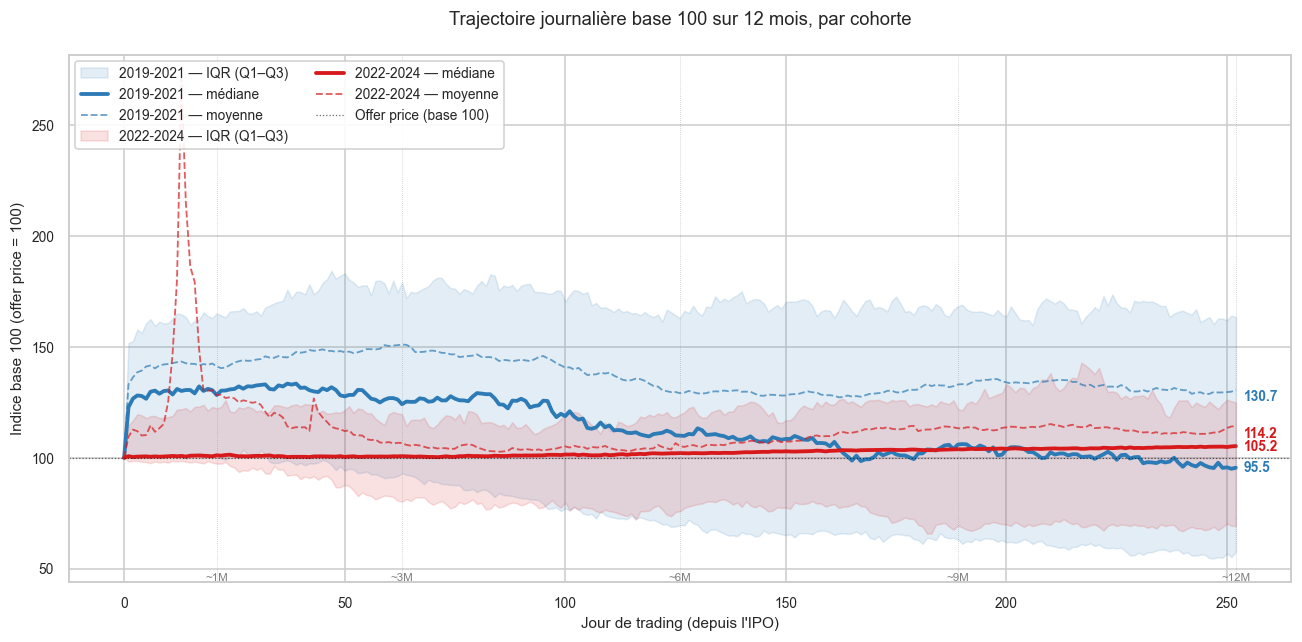

Enregistré : trajectoire_base100_12m_agregee.png


In [103]:
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt

# ── Graphique : trajectoire base 100 agrégée sur 12 mois ───────────────────
fig, ax = plt.subplots(figsize=(12, 6))

for c in ['2019-2021', '2022-2024']:
    s = agg[agg['cohort'] == c].sort_values('trading_day')
    col = COLORS[c]

    # Bande IQR
    ax.fill_between(s['trading_day'], s['q25'], s['q75'],
                    alpha=0.13, color=col, label=f'{c} — IQR (Q1–Q3)')

    # Médiane (trait plein épais)
    ax.plot(s['trading_day'], s['median'], color=col, linewidth=2.5,
            label=f'{c} — médiane')

    # Moyenne (tirets fins)
    ax.plot(s['trading_day'], s['mean'], color=col, linewidth=1.2,
            linestyle='--', alpha=0.7, label=f'{c} — moyenne')

    # Annotation valeur finale
    last = s[s['trading_day'] == s['trading_day'].max()].iloc[0]
    for val, style, va in [(last['median'], 'solid', 'center'),
                            (last['mean'],   'dashed', 'top')]:
        ax.annotate(
            f"{val:.1f}",
            xy=(last['trading_day'], val),
            xytext=(5, 0), textcoords='offset points',
            fontsize=9, color=col, fontweight='bold', va=va
        )

ax.axhline(100, color='black', linewidth=0.8, linestyle=':', alpha=0.6, label='Offer price (base 100)')

# Repères temporels
for d, lbl in [(21, '~1M'), (63, '~3M'), (126, '~6M'), (189, '~9M'), (252, '~12M')]:
    ax.axvline(d, color='grey', linewidth=0.5, linestyle=':', alpha=0.5)
    ax.text(d, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 50,
            lbl, ha='center', fontsize=7.5, color='grey', va='bottom')

ax.set_xlabel('Jour de trading (depuis l\'IPO)')
ax.set_ylabel('Indice base 100 (offer price = 100)')
ax.set_title(
    'Trajectoire journalière base 100 sur 12 mois, par cohorte\n',
    fontsize=12
)
ax.legend(ncol=2, loc='upper left', framealpha=0.9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))

plt.tight_layout()
plt.savefig(IMG_DIR / 'trajectoire_base100_12m_agregee.png', dpi=150, bbox_inches='tight')
plt.show()
print('Enregistré : trajectoire_base100_12m_agregee.png')
